#Data

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# # Download directly to Drive
# !kaggle datasets download -d nih-chest-xrays/data -p /content/drive/MyDrive/mitt/vision/project/chestx

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
100% 42.0G/42.0G [34:11<00:00, 22.0MB/s]



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/mitt/vision/project/chestx'

In [ ]:
import zipfile

with zipfile.ZipFile(path + '/nih_data_sample/nih_data_sample.zip', 'r') as z:
    all_files = z.namelist()

    target_prefix = 'sample/images/'
    image_files = [f for f in all_files if f.startswith(target_prefix) and f.endswith(('.png', '.jpg', '.jpeg'))]
    for image_file in image_files:
        z.extract(image_file, path='data')



In [ ]:
with zipfile.ZipFile(path + '/nih_data_sample/nih_data_sample.zip', 'r') as z:
      z.extract('sample_labels.csv', path='data')

In [ ]:
from collections import Counter
import os

# Set the path where dataset CSV files are stored
data_path = "data"

# Load the Data_Entry_2017.csv file
data_entry_df = pd.read_csv(os.path.join(data_path, "sample_labels.csv"))

# Total number of cases
total_cases = len(data_entry_df)

# --- SECTION 1: Find unique individual finding labels ---
all_individual_labels = []
for labels in data_entry_df['Finding Labels']:
    if pd.notna(labels):
        labels_list = labels.split('|')
        for label in labels_list:
            all_individual_labels.append(label.strip())

unique_individual_labels = sorted(set(all_individual_labels))

print(f"Number of unique individual finding labels: {len(unique_individual_labels)}")

# --- SECTION 2: Unique combinations counts (Your existing logic) ---
label_combinations_counts = data_entry_df['Finding Labels'].dropna().value_counts()
sorted_combinations = sorted(label_combinations_counts.items(), key=lambda x: x[1], reverse=True)

# --- SECTION 3: Individual label counts (New Integrated Logic) ---
# Count occurrences of every individual label across all rows
individual_counts = Counter(all_individual_labels)

print("\nIndividual Label Counts (Total occurrences across all combinations):")
print("Label".ljust(25) + " | " + "Count".ljust(10) + " | " + "Prevalence %")
print("-" * 55)

# Sort by count descending
for label, count in individual_counts.most_common():
    prevalence = (count / total_cases) * 100
    print(f"{label:<25} | {count:<10} | {prevalence:.2f}%")

# --- SECTION 4: Display Combinations ---
print(f"\nNumber of unique possible outcomes (combinations): {len(sorted_combinations)}")
print(f"Total number of cases: {total_cases}")
print("\nUnique combinations of finding labels (Top 25 sorted by frequency):")
print("Combination".ljust(40) + " | " + "Count".ljust(15) + " | " + "Percentage")
print("-" * 70)

for combo, count in sorted_combinations[:25]:
    percentage = (count / total_cases) * 100
    print(f"{combo:<40} | {count:<15} | {percentage:.2f}%")

Number of unique individual finding labels: 15

Individual Label Counts (Total occurrences across all combinations):
Label                     | Count      | Prevalence %
-------------------------------------------------------
No Finding                | 3044       | 54.30%
Infiltration              | 967        | 17.25%
Effusion                  | 644        | 11.49%
Atelectasis               | 508        | 9.06%
Nodule                    | 313        | 5.58%
Mass                      | 284        | 5.07%
Pneumothorax              | 271        | 4.83%
Consolidation             | 226        | 4.03%
Pleural_Thickening        | 176        | 3.14%
Cardiomegaly              | 141        | 2.52%
Emphysema                 | 127        | 2.27%
Edema                     | 118        | 2.10%
Fibrosis                  | 84         | 1.50%
Pneumonia                 | 62         | 1.11%
Hernia                    | 13         | 0.23%

Number of unique possible outcomes (combinations): 244
Total num

#CheXnet Replication

from: An Open-Source Reproduction and Enhancement of CheXNet for Chest X-ray Disease Classification
https://arxiv.org/abs/2505.06646

- https://github.com/dstrick17/DacNet/blob/main/scripts/replicate_chexnet.py

original ChexNet paper: Rajpurkar et al.
CheXNet: Radiologist-Level Pneumonia Detection on Chest X-Rays with Deep Learning
https://arxiv.org/abs/1711.05225


In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from tqdm.auto import tqdm
import wandb
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np
from torchvision.models import densenet121, DenseNet121_Weights
import time

In [ ]:
# Configuration settings
CONFIG = {
    "model": "train_chexnet",
    "batch_size": 16,
    "learning_rate": 0.001,  # Adjusted learning rate
    "epochs": 20,  # Adjusted epochs
    "num_workers": 8,
    "device": "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu",
    "data_dir": "data/samples/images",
    "wandb_project": "X-Ray Classification",
    "patience": 5,
    "seed": 42,
    "image_size": 224,  # Consistent image size
}

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize(224),                   # downscale to 224×224 as stated
    transforms.RandomHorizontalFlip(),        # only augmentation they mention
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


transform_test = transforms.Compose([
    transforms.Resize(224),                   # just resize, no center crop
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
# Load the CSV file with image metadata
data_path = CONFIG["data_dir"] #data/samples/images
csv_file = os.path.join('data', "sample_labels.csv")
df = pd.read_csv(csv_file)
df = df[df['View Position'].isin(['PA', 'AP'])]

In [ ]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


In [ ]:
# Unique patient IDs
unique_patients = df['Patient ID'].unique()

# Split patients — not rows
train_val_patients, test_patients = train_test_split(
          unique_patients, test_size=0.02, random_state=CONFIG["seed"]
)

train_patients, val_patients = train_test_split(
          train_val_patients, test_size=0.052, random_state=CONFIG["seed"]
)

#Use those patients to filter full image rows
train_df = df[df['Patient ID'].isin(train_patients)]
val_df   = df[df['Patient ID'].isin(val_patients)]
test_df  = df[df['Patient ID'].isin(test_patients)]

In [ ]:
# List of diseases we’re classifying
disease_list = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# Function to convert label string to a vector
def get_label_vector(labels_str):
    labels = labels_str.split('|')

    if labels == ['No Finding']:
        return [0] * len(disease_list)

    else:
        return [1 if disease in labels else 0 for disease in disease_list]

In [ ]:
# Custom Dataset class SAMPLE DATASET
class CheXNetDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.path = 'data/sample/images'
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['Image Index']

        img_path = os.path.join(self.path, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        labels_str = self.dataframe.iloc[idx]['Finding Labels']
        label_vector = get_label_vector(labels_str)
        labels = torch.tensor(label_vector, dtype=torch.float)

        return image, labels

In [ ]:
# Set up DataLoaders with our custom datasets
train_dataset = CheXNetDataset(train_df, transform=transform_train)
val_dataset = CheXNetDataset(val_df,  transform=transform_test)
test_dataset = CheXNetDataset(test_df, transform=transform_test)

trainloader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
valloader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
testloader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

In [ ]:
disease_list = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

In [ ]:
def evaluate(model, testloader, criterion, device, desc="[Test]"):

    model.eval()
    running_loss = 0.0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        progress_bar = tqdm(testloader, desc=desc, leave=True)

        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Use sigmoid for multi-label probabilities
            preds = torch.sigmoid(outputs)

            all_labels.append(labels.cpu())
            all_preds.append(preds.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()
    test_loss = running_loss / len(testloader)

    auc_scores = []
    auc_dict = {}

    # 1. Compute AUC for each class with safety check
    for i, disease in enumerate(disease_list):
        # Check if both classes (0 and 1) exist in this specific column
        if len(np.unique(all_labels[:, i])) > 1:
            score = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores.append(score)
            auc_dict[disease] = score
            print(f"{desc} {disease} AUC-ROC: {score:.4f}")
        else:
            # If only one class is present, AUC is technically undefined
            auc_dict[disease] = float('nan')
            print(f"{desc} {disease} AUC-ROC: N/A (Only one class present in sample)")

    # Use nanmean to ignore classes where AUC couldn't be calculated
    avg_auc = np.nanmean(list(auc_dict.values()))

    # 2. Compute binary predictions
    preds_binary = (all_preds > 0.5).astype(int)

    # 3. Per-class F1 scores with zero_division fix
    f1_dict = {}
    for i, disease in enumerate(disease_list):
        # zero_division=0 prevents the warning and sets score to 0 if no samples exist
        score = f1_score(all_labels[:, i], preds_binary[:, i], zero_division=0)
        f1_dict[disease] = score
        print(f"{desc} {disease} F1 Score: {score:.4f}")

    avg_f1 = np.mean(list(f1_dict.values()))

    print(f"\n{desc} SUMMARY")
    print(f"Loss: {test_loss:.4f}, Avg AUC-ROC: {avg_auc:.4f}, Avg F1 Score: {avg_f1:.4f}")

    return test_loss, avg_auc, avg_f1, auc_dict, f1_dict

In [ ]:
# Load and modify the model
model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
model.classifier = nn.Linear(model.classifier.in_features, 14)
model = model.to(CONFIG["device"])

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=1e-5) #Added weight decay.
# betas=(0.9, 0.999) - this is default in pytorch

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=1, factor=0.1)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 78.0MB/s]


In [ ]:
def train(epoch, model, trainloader, optimizer, criterion, CONFIG):
    device = CONFIG["device"]
    model.train()

    running_loss = 0.0
    progress_bar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Train]", leave=True)

    for i, (inputs, labels) in enumerate(progress_bar):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress_bar.set_postfix({"loss": running_loss / (i + 1)})

    train_loss = running_loss / len(trainloader)
    return train_loss

def validate(model, valloader, criterion, device):
    val_loss, val_auc, val_f1, auc_dict, f1_dict = evaluate(model, valloader, criterion, device, desc="[Validate]")
    return val_loss, val_auc, val_f1, auc_dict, f1_dict

In [ ]:
 # Training loop with WandB and timestamped checkpoints
wandb.init(project=CONFIG["wandb_project"], config=CONFIG)
wandb.watch(model, log="all")

run_id = wandb.run.id
checkpoint_dir = os.path.join("models", run_id)
os.makedirs(checkpoint_dir, exist_ok=True)

best_val_auc = 0.0
patience_counter = 0

for epoch in range(CONFIG["epochs"]):
    train_loss = train(epoch, model, trainloader, optimizer, criterion, CONFIG)
    val_loss, val_auc, val_f1, auc_dict, f1_dict = validate(model, valloader, criterion, CONFIG["device"])
    scheduler.step(val_loss)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auc": val_auc,
        "val_f1": val_f1,
        "f1_dict": f1_dict,
        "auc_dict": auc_dict,
    })

    if val_auc > best_val_auc:
        best_val_auc = val_auc

        patience_counter = 0
        timestamp = time.strftime("%Y%m%d-%H%M%S")

        checkpoint_path = os.path.join(checkpoint_dir, f"best_model_{timestamp}.pth")
        torch.save(model.state_dict(), checkpoint_path)
        wandb.save(checkpoint_path)

    else:
        patience_counter += 1

        if patience_counter >= CONFIG["patience"]:
            print("Early stopping triggered.")
            break

# Evaluate the best model
best_checkpoint_path = sorted([os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.startswith('best_model_')])[-1]
model.load_state_dict(torch.load(best_checkpoint_path))
test_loss, test_auc, test_f1, auc_dict, f1_dict = evaluate(model, testloader, criterion, CONFIG["device"])

wandb.log({
    "test_loss": test_loss,
    "test_auc": test_auc,
    "test_f1": test_f1,
    "test_auc_dict": auc_dict,
    "test_f1_dict": f1_dict
})

wandb.finish()

Epoch 1/20 [Train]:   0%|          | 0/325 [00:00<?, ?it/s]

[Validate]:   0%|          | 0/20 [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


[Validate] Atelectasis AUC-ROC: 0.5776
[Validate] Cardiomegaly AUC-ROC: 0.5623
[Validate] Consolidation AUC-ROC: 0.7392
[Validate] Edema AUC-ROC: 0.8837
[Validate] Effusion AUC-ROC: 0.7519
[Validate] Emphysema AUC-ROC: 0.8035
[Validate] Fibrosis AUC-ROC: 0.3907
[Validate] Hernia AUC-ROC: N/A (Only one class present in sample)
[Validate] Infiltration AUC-ROC: 0.7159
[Validate] Mass AUC-ROC: 0.6660
[Validate] Nodule AUC-ROC: 0.5038
[Validate] Pleural_Thickening AUC-ROC: 0.7972
[Validate] Pneumonia AUC-ROC: 0.6031
[Validate] Pneumothorax AUC-ROC: 0.6513
[Validate] Atelectasis F1 Score: 0.0000
[Validate] Cardiomegaly F1 Score: 0.0000
[Validate] Consolidation F1 Score: 0.0000
[Validate] Edema F1 Score: 0.0000
[Validate] Effusion F1 Score: 0.0000
[Validate] Emphysema F1 Score: 0.0000
[Validate] Fibrosis F1 Score: 0.0000
[Validate] Hernia F1 Score: 0.0000
[Validate] Infiltration F1 Score: 0.0312
[Validate] Mass F1 Score: 0.0000
[Validate] Nodule F1 Score: 0.0000
[Validate] Pleural_Thickening 

Epoch 2/20 [Train]:   0%|          | 0/325 [00:00<?, ?it/s]

...

[Validate]:   0%|          | 0/20 [00:00<?, ?it/s]

[Validate] Atelectasis AUC-ROC: 0.7642
[Validate] Cardiomegaly AUC-ROC: 0.6012
[Validate] Consolidation AUC-ROC: 0.8108
[Validate] Edema AUC-ROC: 0.9266
[Validate] Effusion AUC-ROC: 0.8234
[Validate] Emphysema AUC-ROC: 0.8848
[Validate] Fibrosis AUC-ROC: 0.5272
[Validate] Hernia AUC-ROC: N/A (Only one class present in sample)
[Validate] Infiltration AUC-ROC: 0.6931
[Validate] Mass AUC-ROC: 0.7991
[Validate] Nodule AUC-ROC: 0.5984
[Validate] Pleural_Thickening AUC-ROC: 0.8386
[Validate] Pneumonia AUC-ROC: 0.7588
[Validate] Pneumothorax AUC-ROC: 0.7787
[Validate] Atelectasis F1 Score: 0.0000
[Validate] Cardiomegaly F1 Score: 0.0000
[Validate] Consolidation F1 Score: 0.0000
[Validate] Edema F1 Score: 0.0000
[Validate] Effusion F1 Score: 0.2807
[Validate] Emphysema F1 Score: 0.0000
[Validate] Fibrosis F1 Score: 0.0000
[Validate] Hernia F1 Score: 0.0000
[Validate] Infiltration F1 Score: 0.2222
[Validate] Mass F1 Score: 0.0000
[Validate] Nodule F1 Score: 0.0000
[Validate] Pleural_Thickening 

[Test]:   0%|          | 0/7 [00:00<?, ?it/s]

[Test] Atelectasis AUC-ROC: 0.7096
[Test] Cardiomegaly AUC-ROC: 0.5198
[Test] Consolidation AUC-ROC: 0.9307
[Test] Edema AUC-ROC: 0.8133
[Test] Effusion AUC-ROC: 0.8231
[Test] Emphysema AUC-ROC: 0.8712
[Test] Fibrosis AUC-ROC: 0.8627
[Test] Hernia AUC-ROC: N/A (Only one class present in sample)
[Test] Infiltration AUC-ROC: 0.6724
[Test] Mass AUC-ROC: 0.5510
[Test] Nodule AUC-ROC: 0.5300
[Test] Pleural_Thickening AUC-ROC: 0.7551
[Test] Pneumonia AUC-ROC: 0.9706
[Test] Pneumothorax AUC-ROC: 0.7433
[Test] Atelectasis F1 Score: 0.0000
[Test] Cardiomegaly F1 Score: 0.0000
[Test] Consolidation F1 Score: 0.0000
[Test] Edema F1 Score: 0.0000
[Test] Effusion F1 Score: 0.3000
[Test] Emphysema F1 Score: 0.0000
[Test] Fibrosis F1 Score: 0.0000
[Test] Hernia F1 Score: 0.0000
[Test] Infiltration F1 Score: 0.0000
[Test] Mass F1 Score: 0.0000
[Test] Nodule F1 Score: 0.0000
[Test] Pleural_Thickening F1 Score: 0.0000
[Test] Pneumonia F1 Score: 0.0000
[Test] Pneumothorax F1 Score: 0.0000

[Test] SUMMARY


epoch,▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██
test_auc,▁
test_f1,▁
test_loss,▁
train_loss,██▆▆▅▅▄▄▃▂▂▂▁▁▁▁▁
val_auc,▂▁▄▅▆▆▇▇▇▇███████
val_f1,▁▅▃▃▄▅▇█▅▆█▆▇█▆▇█
val_loss,▅█▃▂▂▂▁▁▂▁▁▁▁▁▁▁▁
epoch,17
test_auc,0.75022
test_f1,0.02143


#ViT

from https://github.com/dstrick17/DacNet/blob/main/scripts/vit_transformer.py

In [ ]:
!pip install transformers

In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from tqdm.auto import tqdm
import wandb
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np
#from transformers import ViTForImageClassification, ViTFeatureExtractor
from transformers import ViTForImageClassification, AutoImageProcessor
import time

In [ ]:
from transformers import ViTForImageClassification, AutoImageProcessor

In [ ]:
# Configuration settings
CONFIG = {
    "model": "vit_transformer",
    "batch_size": 16,
    "learning_rate": 0.0001,
    "epochs": 20,
    "num_workers": 1,
    "device": "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu",
    "data_dir": "data/samples/images",
    "wandb_project": "X-Ray Classification",
    "patience": 5,
    "seed": 42,
    "image_size": 224,
}


In [ ]:
# Define the model name and load feature extractor
model_name = "google/vit-base-patch16-224"
feature_extractor = AutoImageProcessor.from_pretrained(model_name, use_fast=True)

# Define transform functions
def transform_train(img):
    return feature_extractor(images=img, return_tensors='pt')['pixel_values'][0]

def transform_test(img):
    return feature_extractor(images=img, return_tensors='pt')['pixel_values'][0]

In [ ]:
# Load the CSV file with image metadata
data_path = CONFIG["data_dir"] #data/samples/images
csv_file = os.path.join('data', "sample_labels.csv")
df = pd.read_csv(csv_file)

In [ ]:
# Patient-level split
unique_patients = df['Patient ID'].unique()
train_val_patients, test_patients = train_test_split(unique_patients, test_size=0.2, random_state=CONFIG["seed"])
train_patients, val_patients = train_test_split(train_val_patients, test_size=0.25, random_state=CONFIG["seed"])
train_df = df[df['Patient ID'].isin(train_patients)]
val_df = df[df['Patient ID'].isin(val_patients)]
test_df = df[df['Patient ID'].isin(test_patients)]

In [ ]:
# Verify splits
print(f"Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}")
if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
    raise ValueError("One or more data splits are empty")

Train size: 3278, Val size: 1184, Test size: 1144


In [ ]:
# Function to convert label string to a vector
def get_label_vector(labels_str):
    labels = labels_str.split('|')
    if labels == ['No Finding']:
        return [0] * len(disease_list)
    else:
        return [1 if disease in labels else 0 for disease in disease_list]

In [ ]:
# Custom Dataset class SAMPLE DATASET
class CheXNetDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.path = 'data/sample/images'
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['Image Index']

        img_path = os.path.join(self.path, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        labels_str = self.dataframe.iloc[idx]['Finding Labels']
        label_vector = get_label_vector(labels_str)
        labels = torch.tensor(label_vector, dtype=torch.float)

        return image, labels

In [ ]:
# Set up DataLoaders
train_dataset = CheXNetDataset(train_df, transform=transform_train)
val_dataset = CheXNetDataset(val_df,  transform=transform_test)
test_dataset = CheXNetDataset(test_df, transform=transform_test)

trainloader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
valloader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
testloader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

In [ ]:
# Load the pre-trained model
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=14,
    ignore_mismatched_sizes=True
)
model = model.to(CONFIG["device"])

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.1)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([14])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([14, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
def evaluate(model, testloader, criterion, device, desc="[Test]"):

    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        progress_bar = tqdm(testloader, desc=desc, leave=True)
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).logits
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = torch.sigmoid(outputs)
            all_labels.append(labels.cpu())
            all_preds.append(preds.cpu())
    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()
    test_loss = running_loss / len(testloader)

    auc_scores = []
    auc_dict = {}

    # 1. Compute AUC for each class with safety check
    for i, disease in enumerate(disease_list):
        # Check if both classes (0 and 1) exist in this specific column
        if len(np.unique(all_labels[:, i])) > 1:
            score = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores.append(score)
            auc_dict[disease] = score
            print(f"{desc} {disease} AUC-ROC: {score:.4f}")
        else:
            # If only one class is present, AUC is technically undefined
            auc_dict[disease] = float('nan')
            print(f"{desc} {disease} AUC-ROC: N/A (Only one class present in sample)")

    # Use nanmean to ignore classes where AUC couldn't be calculated
    avg_auc = np.nanmean(list(auc_dict.values()))

    # 2. Compute binary predictions
    preds_binary = (all_preds > 0.5).astype(int)

    # 3. Per-class F1 scores with zero_division fix
    f1_dict = {}
    for i, disease in enumerate(disease_list):
        # zero_division=0 prevents the warning and sets score to 0 if no samples exist
        score = f1_score(all_labels[:, i], preds_binary[:, i], zero_division=0)
        f1_dict[disease] = score
        print(f"{desc} {disease} F1 Score: {score:.4f}")

    avg_f1 = np.mean(list(f1_dict.values()))

    print(f"\n{desc} SUMMARY")
    print(f"Loss: {test_loss:.4f}, Avg AUC-ROC: {avg_auc:.4f}, Avg F1 Score: {avg_f1:.4f}")

    return test_loss, avg_auc, avg_f1, auc_dict, f1_dict

In [ ]:
# Training function
def train(epoch, model, trainloader, optimizer, criterion, CONFIG):
    device = CONFIG["device"]
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Train]", leave=True)
    # Ensure progress_bar is closed properly
    try:
        for i, (inputs, labels) in enumerate(progress_bar):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).logits
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            progress_bar.set_postfix({"loss": running_loss / (i + 1)})
    finally:
        progress_bar.close()
    train_loss = running_loss / len(trainloader)
    return train_loss

def validate(model, valloader, criterion, device):
    val_loss, val_auc, val_f1, auc_dict, f1_dict = evaluate(model, valloader, criterion, device, desc="[Validate]")
    return val_loss, val_auc, val_f1, auc_dict, f1_dict

In [ ]:
# Training loop
try:
    wandb.init(project=CONFIG["wandb_project"], config=CONFIG)
    wandb.watch(model)
except Exception as e:
    print(f"WandB initialization failed: {e}. Continuing without WandB.")
    wandb.init(mode="disabled")

run_id = wandb.run.id
DRIVE_CKPT_DIR = path + '/models'
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
checkpoint_dir = os.path.join(DRIVE_CKPT_DIR, run_id)

best_val_auc = 0.0
patience_counter = 0

for epoch in range(CONFIG["epochs"]):
    train_loss = train(epoch, model, trainloader, optimizer, criterion, CONFIG)
    val_loss, val_auc, val_f1, auc_dict, f1_dict = validate(model, valloader, criterion, CONFIG["device"])
    scheduler.step(val_loss)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auc": val_auc,
        "val_f1": val_f1,
        "f1_dict": f1_dict,
        "auc_dict": auc_dict,
    })

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        timestamp = time.strftime("%Y%m%d-%H%M%S")
         checkpoint_path = os.path.join(
            DRIVE_CKPT_DIR,
            f"best_model_{run_id}_{timestamp}.pth"
        )

        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_auc": val_auc,
            "config": CONFIG
        }, checkpoint_path)

        best_checkpoint_path = checkpoint_path

        print(f"Saved best model to Drive: {checkpoint_path}")

        # log artifact (optional, lightweight)
        wandb.save(checkpoint_path)

    else:
        patience_counter += 1
        if patience_counter >= CONFIG["patience"]:
            print("Early stopping triggered.")
            break

# Evaluate the best model

if best_checkpoint_path is None:
    raise FileNotFoundError("No best model was saved.")

checkpoint = torch.load(best_checkpoint_path, map_location=CONFIG["device"])

model.load_state_dict(checkpoint["model_state_dict"])
print("Loaded best model from:", best_checkpoint_path)

test_loss, test_auc, test_f1, auc_dict, f1_dict = evaluate(model, testloader, criterion, CONFIG["device"])
wandb.log({
    "test_loss": test_loss,
    "test_auc": test_auc,
    "test_f1": test_f1,
    "test_auc_dict": auc_dict,
    "test_f1_dict": f1_dict
})

wandb.finish()

Epoch 1/20 [Train]:   0%|          | 0/205 [00:00<?, ?it/s]

[Validate]:   0%|          | 0/74 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a1cb79e44a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
      Exception ignored in:  ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a1cb79e44a0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    
if w.is_alive():  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

     assert self._parent_pid == os.getpid(), 'can only test a child process' 
          ^ ^ ^ ^ ^ ^ ^^^^^^^^^^^^
^  Fil

[Validate] Atelectasis AUC-ROC: 0.7420
[Validate] Cardiomegaly AUC-ROC: 0.6019
[Validate] Consolidation AUC-ROC: 0.8107
[Validate] Edema AUC-ROC: 0.8164
[Validate] Effusion AUC-ROC: 0.7907
[Validate] Emphysema AUC-ROC: 0.7698
[Validate] Fibrosis AUC-ROC: 0.7163
[Validate] Hernia AUC-ROC: 0.5876
[Validate] Infiltration AUC-ROC: 0.6831
[Validate] Mass AUC-ROC: 0.6359
[Validate] Nodule AUC-ROC: 0.6962
[Validate] Pleural_Thickening AUC-ROC: 0.7320
[Validate] Pneumonia AUC-ROC: 0.5149
[Validate] Pneumothorax AUC-ROC: 0.7864
[Validate] Atelectasis F1 Score: 0.0000
[Validate] Cardiomegaly F1 Score: 0.0000
[Validate] Consolidation F1 Score: 0.0000
[Validate] Edema F1 Score: 0.0000
[Validate] Effusion F1 Score: 0.1268
[Validate] Emphysema F1 Score: 0.0000
[Validate] Fibrosis F1 Score: 0.0000
[Validate] Hernia F1 Score: 0.0000
[Validate] Infiltration F1 Score: 0.0000
[Validate] Mass F1 Score: 0.0000
[Validate] Nodule F1 Score: 0.0000
[Validate] Pleural_Thickening F1 Score: 0.0000
[Validate] Pneu

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


...

[Validate]:   0%|          | 0/74 [00:00<?, ?it/s]

[Validate] Atelectasis AUC-ROC: 0.7194
[Validate] Cardiomegaly AUC-ROC: 0.7327
[Validate] Consolidation AUC-ROC: 0.7737
[Validate] Edema AUC-ROC: 0.8113
[Validate] Effusion AUC-ROC: 0.7367
[Validate] Emphysema AUC-ROC: 0.7963
[Validate] Fibrosis AUC-ROC: 0.7060
[Validate] Hernia AUC-ROC: 0.6349
[Validate] Infiltration AUC-ROC: 0.6309
[Validate] Mass AUC-ROC: 0.6324
[Validate] Nodule AUC-ROC: 0.7088
[Validate] Pleural_Thickening AUC-ROC: 0.7453
[Validate] Pneumonia AUC-ROC: 0.5546
[Validate] Pneumothorax AUC-ROC: 0.7719
[Validate] Atelectasis F1 Score: 0.1259
[Validate] Cardiomegaly F1 Score: 0.0588
[Validate] Consolidation F1 Score: 0.0000
[Validate] Edema F1 Score: 0.0000
[Validate] Effusion F1 Score: 0.3173
[Validate] Emphysema F1 Score: 0.0000
[Validate] Fibrosis F1 Score: 0.0000
[Validate] Hernia F1 Score: 0.0000
[Validate] Infiltration F1 Score: 0.2215
[Validate] Mass F1 Score: 0.1026
[Validate] Nodule F1 Score: 0.1562
[Validate] Pleural_Thickening F1 Score: 0.0000
[Validate] Pneu

[Test]:   0%|          | 0/72 [00:00<?, ?it/s]

[Test] Atelectasis AUC-ROC: 0.7422
[Test] Cardiomegaly AUC-ROC: 0.6523
[Test] Consolidation AUC-ROC: 0.7153
[Test] Edema AUC-ROC: 0.7735
[Test] Effusion AUC-ROC: 0.7778
[Test] Emphysema AUC-ROC: 0.7864
[Test] Fibrosis AUC-ROC: 0.5842
[Test] Hernia AUC-ROC: 0.6891
[Test] Infiltration AUC-ROC: 0.6722
[Test] Mass AUC-ROC: 0.6704
[Test] Nodule AUC-ROC: 0.5969
[Test] Pleural_Thickening AUC-ROC: 0.6676
[Test] Pneumonia AUC-ROC: 0.6896
[Test] Pneumothorax AUC-ROC: 0.7924
[Test] Atelectasis F1 Score: 0.0430
[Test] Cardiomegaly F1 Score: 0.0000
[Test] Consolidation F1 Score: 0.0000
[Test] Edema F1 Score: 0.0000
[Test] Effusion F1 Score: 0.1361
[Test] Emphysema F1 Score: 0.0000
[Test] Fibrosis F1 Score: 0.0000
[Test] Hernia F1 Score: 0.0000
[Test] Infiltration F1 Score: 0.1388
[Test] Mass F1 Score: 0.0000
[Test] Nodule F1 Score: 0.0000
[Test] Pleural_Thickening F1 Score: 0.0000
[Test] Pneumonia F1 Score: 0.0000
[Test] Pneumothorax F1 Score: 0.0339

[Test] SUMMARY
Loss: 0.1719, Avg AUC-ROC: 0.700

epoch,▁▂▃▅▆▇█
test_auc,▁
test_f1,▁
test_loss,▁
train_loss,█▇▇▅▃▂▁
val_auc,▃█▁█▃▄▄
val_f1,▁▃▅▇▇██
val_loss,▁▁▂▄█▇█
epoch,7
test_auc,0.7007
test_f1,0.02512


In [ ]:

wandb.finish()

#Vanilla Hybrid

Simply combine features

In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from tqdm.auto import tqdm
import wandb
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np
from torchvision.models import densenet121, DenseNet121_Weights
from transformers import ViTForImageClassification, AutoImageProcessor, ViTModel
import time

In [ ]:
# Configuration settings
CONFIG = {
    "model": "hybrid_cnn_vit",
    "batch_size": 16,
    "learning_rate": 0.001,  # Adjusted learning rate
    "epochs": 20,  # Adjusted epochs
    "num_workers": 0,
    "device": "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu",
    "data_dir": "data/samples/images",
    "wandb_project": "X-Ray Classification",
    "patience": 5,
    "seed": 42,
    "image_size": 224,
}

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize(224),                   # downscale to 224×224 as stated
    transforms.RandomHorizontalFlip(),        # only augmentation they mention
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


transform_test = transforms.Compose([
    transforms.Resize(224),                   # just resize, no center crop
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

feature_extractor = AutoImageProcessor.from_pretrained(model_name, use_fast=True)

# Define transform functions
def transform_train(img):
    return feature_extractor(images=img, return_tensors='pt')['pixel_values'][0]

def transform_test(img):
    return feature_extractor(images=img, return_tensors='pt')['pixel_values'][0]

In [ ]:
# Load the CSV file with image metadata
data_path = CONFIG["data_dir"] #data/samples/images
csv_file = os.path.join('data', "sample_labels.csv")
df = pd.read_csv(csv_file)
df = df[df['View Position'].isin(['PA', 'AP'])]

In [ ]:
# Unique patient IDs
unique_patients = df['Patient ID'].unique()

# Split patients — not rows
train_val_patients, test_patients = train_test_split(
          unique_patients, test_size=0.02, random_state=CONFIG["seed"]
)

train_patients, val_patients = train_test_split(
          train_val_patients, test_size=0.052, random_state=CONFIG["seed"]
)

#Use those patients to filter full image rows
train_df = df[df['Patient ID'].isin(train_patients)]
val_df   = df[df['Patient ID'].isin(val_patients)]
test_df  = df[df['Patient ID'].isin(test_patients)]

In [ ]:
# List of diseases we’re classifying
disease_list = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# Function to convert label string to a vector
def get_label_vector(labels_str):
    labels = labels_str.split('|')

    if labels == ['No Finding']:
        return [0] * len(disease_list)

    else:
        return [1 if disease in labels else 0 for disease in disease_list]

In [ ]:
# Custom Dataset class SAMPLE DATASET
class HybridDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.path = 'data/sample/images'
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['Image Index']

        img_path = os.path.join(self.path, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        labels_str = self.dataframe.iloc[idx]['Finding Labels']
        label_vector = get_label_vector(labels_str)
        labels = torch.tensor(label_vector, dtype=torch.float)

        return image, labels

In [ ]:
# Set up DataLoaders with our custom datasets
train_dataset = HybridDataset(train_df, transform=transform_train)
val_dataset = HybridDataset(val_df,  transform=transform_test)
test_dataset = HybridDataset(test_df, transform=transform_test)

trainloader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
valloader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
testloader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

In [ ]:
def evaluate(model, testloader, criterion, device, desc="[Test]"):

    model.eval()
    running_loss = 0.0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        progress_bar = tqdm(testloader, desc=desc, leave=True)

        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Use sigmoid for multi-label probabilities
            preds = torch.sigmoid(outputs)

            all_labels.append(labels.cpu())
            all_preds.append(preds.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()
    test_loss = running_loss / len(testloader)

    auc_scores = []
    auc_dict = {}

    # 1. Compute AUC for each class with safety check
    for i, disease in enumerate(disease_list):
        # Check if both classes (0 and 1) exist in this specific column
        if len(np.unique(all_labels[:, i])) > 1:
            score = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores.append(score)
            auc_dict[disease] = score
            print(f"{desc} {disease} AUC-ROC: {score:.4f}")
        else:
            # If only one class is present, AUC is technically undefined
            auc_dict[disease] = float('nan')
            print(f"{desc} {disease} AUC-ROC: N/A (Only one class present in sample)")

    # Use nanmean to ignore classes where AUC couldn't be calculated
    avg_auc = np.nanmean(list(auc_dict.values()))

    # 2. Compute binary predictions
    preds_binary = (all_preds > 0.5).astype(int)

    # 3. Per-class F1 scores with zero_division fix
    f1_dict = {}
    for i, disease in enumerate(disease_list):
        # zero_division=0 prevents the warning and sets score to 0 if no samples exist
        score = f1_score(all_labels[:, i], preds_binary[:, i], zero_division=0)
        f1_dict[disease] = score
        print(f"{desc} {disease} F1 Score: {score:.4f}")

    avg_f1 = np.mean(list(f1_dict.values()))

    print(f"\n{desc} SUMMARY")
    print(f"Loss: {test_loss:.4f}, Avg AUC-ROC: {avg_auc:.4f}, Avg F1 Score: {avg_f1:.4f}")

    return test_loss, avg_auc, avg_f1, auc_dict, f1_dict

In [ ]:
class HybridModel(nn.Module):
    def __init__(self, num_labels=14):
        super(HybridModel, self).__init__()

        # 1. Load CNN Backbone (DenseNet121)
        self.cnn = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        self.cnn.classifier = nn.Identity() # Remove original head

        # 2. Load ViT Backbone
        self.vit_model = ViTForImageClassification.from_pretrained(
            "google/vit-base-patch16-224",
            num_labels=num_labels,
            ignore_mismatched_sizes=True,
            attn_implementation='eager'
        )
        self.vit = self.vit_model.vit # Keep only the transformer backbone

        # 3. Hybrid Classifier Head
        # DenseNet (1024) + ViT Base (768) = 1792
        self.classifier = nn.Sequential(
            nn.Linear(1024 + 768, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_labels)
        )

    def forward(self, x):
        # x is the same image tensor for both
        feat_cnn = self.cnn(x) # Output: [batch, 1024]

        vit_output = self.vit(x)
        feat_vit = vit_output.last_hidden_state[:, 0] # Output: [batch, 768] (CLS token)

        # Concatenate features
        combined = torch.cat((feat_cnn, feat_vit), dim=1)

        logits = self.classifier(feat)
        return logits

In [ ]:
# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
#optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=1e-5) #Added weight decay.
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=1, factor=0.1)

In [ ]:
# Training function
def train(epoch, model, trainloader, optimizer, criterion, CONFIG):
    device = CONFIG["device"]
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Train]", leave=True)
    # Ensure progress_bar is closed properly
    try:
        for i, (inputs, labels) in enumerate(progress_bar):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            progress_bar.set_postfix({"loss": running_loss / (i + 1)})
    finally:
        progress_bar.close()
    train_loss = running_loss / len(trainloader)
    return train_loss

def validate(model, valloader, criterion, device):
    val_loss, val_auc, val_f1, auc_dict, f1_dict = evaluate(model, valloader, criterion, device, desc="[Validate]")
    return val_loss, val_auc, val_f1, auc_dict, f1_dict

In [ ]:
def initialize_hybrid(cnn_pth, vit_pth, device):
    model = HybridModel(num_labels=14).to(device)

    # Helper to clean 'module.' and load weights
    def load_weights_selective(target_submodel, pth_path):
        state_dict = torch.load(pth_path, map_location=device)
        if 'state_dict' in state_dict: state_dict = state_dict['state_dict']
        new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()
                         if not k.startswith('classifier')} # Exclude old heads
        target_submodel.load_state_dict(new_state_dict, strict=False)

    # Load into respective sub-parts
    load_weights_selective(model.cnn, cnn_pth)
    load_weights_selective(model.vit_model, vit_pth) # Loads into vit-backbone part

    # Explicitly set output_attentions to True for the ViT model's config
    model.vit_model.config.output_attentions = True

    return model

cnn_pth = "/content/artifacts/CheXNet-sample:v0/best_model_20260507-031207.pth"
vit_pth = "/content/artifacts/vit-sample:v0/best_model_20260507-035340.pth"
hybrid_model = initialize_hybrid(cnn_pth, vit_pth, CONFIG['device'])

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([14])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([14, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
 # Training loop with WandB and timestamped checkpoints
wandb.init(project=CONFIG["wandb_project"], config=CONFIG)
wandb.watch(model, log="all")

run_id = wandb.run.id
checkpoint_dir = os.path.join("models", run_id)
os.makedirs(checkpoint_dir, exist_ok=True)

best_val_auc = 0.0
patience_counter = 0

for epoch in range(CONFIG["epochs"]):
    train_loss = train(epoch, model, trainloader, optimizer, criterion, CONFIG)
    val_loss, val_auc, val_f1, auc_dict, f1_dict = validate(model, valloader, criterion, CONFIG["device"])
    scheduler.step(val_loss)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auc": val_auc,
        "val_f1": val_f1,
        "f1_dict": f1_dict,
        "auc_dict": auc_dict,
    })

    if val_auc > best_val_auc:
        best_val_auc = val_auc

        patience_counter = 0
        timestamp = time.strftime("%Y%m%d-%H%M%S")

        checkpoint_path = os.path.join(checkpoint_dir, f"best_model_{timestamp}.pth")
        torch.save(model.state_dict(), checkpoint_path)
        wandb.save(checkpoint_path)

    else:
        patience_counter += 1

        if patience_counter >= CONFIG["patience"]:
            print("Early stopping triggered.")
            break

# Evaluate the best model
best_checkpoint_path = sorted([os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.startswith('best_model_')])[-1]
model.load_state_dict(torch.load(best_checkpoint_path))
test_loss, test_auc, test_f1, auc_dict, f1_dict = evaluate(model, testloader, criterion, CONFIG["device"])

wandb.log({
    "test_loss": test_loss,
    "test_auc": test_auc,
    "test_f1": test_f1,
    "test_auc_dict": auc_dict,
    "test_f1_dict": f1_dict
})

wandb.finish()

#Hybrid Model

Projection Heads then Fusion

In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from tqdm import tqdm
import wandb
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np
from torchvision.models import densenet121, DenseNet121_Weights
from transformers import ViTForImageClassification, AutoImageProcessor, ViTModel
import time
from google.colab import userdata

In [ ]:
os.environ["WANDB_API_KEY"] = userdata.get("WANDB")

In [ ]:
wandb.finish()

In [ ]:
# Configuration settings
CONFIG = {
    "model": "hybrid_cnn_vit",
    "batch_size": 16,
    "learning_rate": 0.001,  # Adjusted learning rate
    "epochs": 20,  # Adjusted epochs
    "num_workers": 0,
    "device": "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu",
    "data_dir": "data/samples/images",
    "wandb_project": "X-Ray Classification",
    "patience": 5,
    "seed": 42,
    "image_size": 224,
}

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize(224),                   # downscale to 224×224 as stated
    transforms.RandomHorizontalFlip(),        # only augmentation they mention
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


transform_test = transforms.Compose([
    transforms.Resize(224),                   # just resize, no center crop
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
# Load the CSV file with image metadata
data_path = CONFIG["data_dir"] #data/samples/images
csv_file = os.path.join('data', "sample_labels.csv")
df = pd.read_csv(csv_file)
df = df[df['View Position'].isin(['PA', 'AP'])]

# Unique patient IDs
unique_patients = df['Patient ID'].unique()

# Split patients — not rows
train_val_patients, test_patients = train_test_split(
          unique_patients, test_size=0.02, random_state=CONFIG["seed"]
)

train_patients, val_patients = train_test_split(
          train_val_patients, test_size=0.052, random_state=CONFIG["seed"]
)

#Use those patients to filter full image rows
train_df = df[df['Patient ID'].isin(train_patients)]
val_df   = df[df['Patient ID'].isin(val_patients)]
test_df  = df[df['Patient ID'].isin(test_patients)]

In [ ]:
# List of diseases we’re classifying
disease_list = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# Function to convert label string to a vector
def get_label_vector(labels_str):
    labels = labels_str.split('|')

    if labels == ['No Finding']:
        return [0] * len(disease_list)

    else:
        return [1 if disease in labels else 0 for disease in disease_list]

In [ ]:
# Custom Dataset class SAMPLE DATASET
class HybridDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.path = 'data/sample/images'
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['Image Index']

        img_path = os.path.join(self.path, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        labels_str = self.dataframe.iloc[idx]['Finding Labels']
        label_vector = get_label_vector(labels_str)
        labels = torch.tensor(label_vector, dtype=torch.float)

        return image, labels

In [ ]:
# Set up DataLoaders with our custom datasets
train_dataset = HybridDataset(train_df, transform=transform_train)
val_dataset = HybridDataset(val_df,  transform=transform_test)
test_dataset = HybridDataset(test_df, transform=transform_test)

trainloader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
valloader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
testloader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

In [ ]:
def evaluate(model, testloader, criterion, device, desc="[Test]"):
    print('eval')
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        progress_bar = tqdm(testloader, desc=desc, leave=True)

        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Use sigmoid for multi-label probabilities
            preds = torch.sigmoid(outputs)

            all_labels.append(labels.cpu())
            all_preds.append(preds.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()
    test_loss = running_loss / len(testloader)

    auc_scores = []
    auc_dict = {}

    # 1. Compute AUC for each class with safety check
    for i, disease in enumerate(disease_list):
        # Check if both classes (0 and 1) exist in this specific column
        if len(np.unique(all_labels[:, i])) > 1:
            score = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores.append(score)
            auc_dict[disease] = score
            print(f"{desc} {disease} AUC-ROC: {score:.4f}")
        else:
            # If only one class is present, AUC is technically undefined
            auc_dict[disease] = float('nan')
            print(f"{desc} {disease} AUC-ROC: N/A (Only one class present in sample)")

    # Use nanmean to ignore classes where AUC couldn't be calculated
    avg_auc = np.nanmean(list(auc_dict.values()))

    # 2. Compute binary predictions
    preds_binary = (all_preds > 0.5).astype(int)

    # 3. Per-class F1 scores with zero_division fix
    f1_dict = {}
    for i, disease in enumerate(disease_list):
        # zero_division=0 prevents the warning and sets score to 0 if no samples exist
        score = f1_score(all_labels[:, i], preds_binary[:, i], zero_division=0)
        f1_dict[disease] = score
        print(f"{desc} {disease} F1 Score: {score:.4f}")

    avg_f1 = np.mean(list(f1_dict.values()))

    print(f"\n{desc} SUMMARY")
    print(f"Loss: {test_loss:.4f}, Avg AUC-ROC: {avg_auc:.4f}, Avg F1 Score: {avg_f1:.4f}")

    return test_loss, avg_auc, avg_f1, auc_dict, f1_dict

In [ ]:
wandb.finish()

In [ ]:
# Training function
def train(epoch, model, trainloader, optimizer, criterion, CONFIG):
    print('train', flush=True)
    device = CONFIG["device"]
    model.train()
    print('hello')
    running_loss = 0.0
    progress_bar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Train]", leave=True)
    print('hi')
    print("trainloader length:", len(trainloader))

    batch = next(iter(trainloader))
    print("FIRST BATCH OK:", type(batch))
    # Ensure progress_bar is closed properly
    try:
        for i, (inputs, labels) in enumerate(progress_bar):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            progress_bar.set_postfix({"loss": running_loss / (i + 1)})
    finally:
        progress_bar.close()
    train_loss = running_loss / len(trainloader)
    return train_loss

def validate(model, valloader, criterion, device):
    print('val')
    val_loss, val_auc, val_f1, auc_dict, f1_dict = evaluate(model, valloader, criterion, device, desc="[Validate]")
    return val_loss, val_auc, val_f1, auc_dict, f1_dict

In [ ]:
class HybridModel(nn.Module):

    def __init__(self, num_labels=14):
        super().__init__()

        # DenseNet Backbone
        self.cnn = densenet121(
            weights=DenseNet121_Weights.IMAGENET1K_V1)
        self.cnn.classifier = nn.Identity()
        # ViT Backbone
        self.vit = ViTModel.from_pretrained(
            "google/vit-base-patch16-224",
            attn_implementation="eager"
        )
        # Projection Heads
        self.cnn_proj = nn.Sequential(
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.vit_proj = nn.Sequential(
            nn.Linear(768, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        # Fusion Classifier
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_labels)
        )
    def forward(self, x):
        cnn_feat = self.cnn(x)

        vit_out = self.vit(pixel_values=x)
        vit_feat = vit_out.last_hidden_state[:, 1:].mean(dim=1) #avg pool

        cnn_feat = self.cnn_proj(cnn_feat)
        vit_feat = self.vit_proj(vit_feat)

        feat = torch.cat([cnn_feat, vit_feat], dim=1)

        logits = self.classifier(feat)
        return logits

In [ ]:
#freeze layers
def freeze_cnn_early_layers(model):
    # Freeze entire CNN first
    for param in model.cnn.parameters():
        param.requires_grad = False
    for name, param in model.cnn.features.named_parameters():

        if (
            "denseblock3" in name or
            "denseblock4" in name or
            "transition3" in name or
            "norm5" in name
        ):
            param.requires_grad = True

def freeze_vit_early_layers(model, freeze_until=8):
    # Freeze patch + positional embeddings
    for param in model.vit.embeddings.parameters():
        param.requires_grad = False
    # Freeze first N transformer blocks
    for idx, block in enumerate(model.vit.encoder.layer):
        if idx < freeze_until:
            for param in block.parameters():
                param.requires_grad = False
        else:
            for param in block.parameters():
                param.requires_grad = True

def freeze_batchnorm_stats(model):
    # Prevent BN running stats updates
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

In [ ]:
def initialize_hybrid(cnn_pth,vit_pth,device,freeze_vit_until=8):
    model = HybridModel(num_labels=14).to(device)

    def load_weights_selective(target_submodel,pth_path,exclude_keywords=None):
        if exclude_keywords is None: exclude_keywords = []
        checkpoint = torch.load(pth_path,map_location=device)

        # Handle checkpoints with state_dict wrapper
        if "state_dict" in checkpoint:
            state_dict = checkpoint["state_dict"]
        else:
            state_dict = checkpoint
        cleaned_state_dict = {}

        for k, v in state_dict.items():
            # Remove DataParallel prefix
            k = k.replace("module.", "")
            # Skip classifier/head layers
            if any(ex_key in k for ex_key in exclude_keywords):
                continue
            cleaned_state_dict[k] = v

        missing, unexpected = target_submodel.load_state_dict(cleaned_state_dict,strict=False)

        print(f"\nLoaded weights from: {pth_path}")
        if len(missing) > 0:
            print(f"Missing keys ({len(missing)}):")
            print(missing)
        if len(unexpected) > 0:
            print(f"Unexpected keys ({len(unexpected)}):")
            print(unexpected)

    load_weights_selective(
        target_submodel=model.cnn,
        pth_path=cnn_pth,
        exclude_keywords=["classifier","fc","head"])

    load_weights_selective(
        target_submodel=model.vit,
        pth_path=vit_pth,
        exclude_keywords=["classifier","head"])

    freeze_cnn_early_layers(model)
    freeze_vit_early_layers(model, freeze_until=freeze_vit_until)
    freeze_batchnorm_stats(model)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)


    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")

    return model

In [ ]:
cnn_pth = "/content/artifacts/CheXNet-sample:v0/best_model_20260507-031207.pth"
vit_pth = "/content/artifacts/vit-sample:v0/best_model_20260507-035340.pth"
model = initialize_hybrid(cnn_pth, vit_pth, CONFIG['device'])



Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Loaded weights from: /content/artifacts/CheXNet-sample:v0/best_model_20260507-031207.pth

Loaded weights from: /content/artifacts/vit-sample:v0/best_model_20260507-035340.pth
Missing keys (200):
['embeddings.cls_token', 'embeddings.position_embeddings', 'embeddings.patch_embeddings.projection.weight', 'embeddings.patch_embeddings.projection.bias', 'encoder.layer.0.attention.attention.query.weight', 'encoder.layer.0.attention.attention.query.bias', 'encoder.layer.0.attention.attention.key.weight', 'encoder.layer.0.attention.attention.key.bias', 'encoder.layer.0.attention.attention.value.weight', 'encoder.layer.0.attention.attention.value.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.intermediate.dense.weight', 'encoder.layer.0.intermediate.dense.bias', 'encoder.layer.0.output.dense.weight', 'encoder.layer.0.output.dense.bias', 'encoder.layer.0.layernorm_before.weight', 'encoder.layer.0.layernorm_before.bias', 'en

In [ ]:
# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),lr=1e-4,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=1, factor=0.1)

In [ ]:
import os
import json
import time
import torch

# ==========================================
# Local training setup
# ==========================================

print("initializing", flush=True)

run_id = time.strftime("%Y%m%d-%H%M%S")

checkpoint_dir = os.path.join("models", run_id)
os.makedirs(checkpoint_dir, exist_ok=True)

print("initialized", flush=True)
print("watching", flush=True)

best_val_auc = 0.0
patience_counter = 0

history = []

print("training", flush=True)

# ==========================================
# Training loop
# ==========================================

for epoch in range(CONFIG["epochs"]):

    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}", flush=True)

    train_loss = train(
        epoch,
        model,
        trainloader,
        optimizer,
        criterion,
        CONFIG
    )

    val_loss, val_auc, val_f1, auc_dict, f1_dict = validate(
        model,
        valloader,
        criterion,
        CONFIG["device"]
    )

    scheduler.step(val_loss)

    # ======================================
    # Save metrics locally
    # ======================================

    epoch_stats = {
        "epoch": epoch + 1,
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "val_auc": float(val_auc),
        "val_f1": float(val_f1),
        "auc_dict": auc_dict,
        "f1_dict": f1_dict
    }

    history.append(epoch_stats)

    metrics_path = os.path.join(
        checkpoint_dir,
        "training_metrics.json"
    )

    with open(metrics_path, "w") as f:
        json.dump(history, f, indent=4)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Val F1: {val_f1:.4f}",
        flush=True
    )

    # ======================================
    # Save best model
    # ======================================

    if val_auc > best_val_auc:

        best_val_auc = val_auc
        patience_counter = 0

        timestamp = time.strftime("%Y%m%d-%H%M%S")

        checkpoint_path = os.path.join(
            checkpoint_dir,
            f"best_model_{timestamp}.pth"
        )

        torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Saved best model: {checkpoint_path}",
            flush=True
        )

    else:

        patience_counter += 1

        print(
            f"No improvement "
            f"({patience_counter}/{CONFIG['patience']})",
            flush=True
        )

        if patience_counter >= CONFIG["patience"]:

            print("Early stopping triggered.", flush=True)
            break

# ==========================================
# Load best model
# ==========================================

checkpoint_files = sorted([
    os.path.join(checkpoint_dir, f)
    for f in os.listdir(checkpoint_dir)
    if f.startswith("best_model_")
])

if len(checkpoint_files) == 0:
    raise FileNotFoundError(
        "No checkpoint files found."
    )

best_checkpoint_path = checkpoint_files[-1]

print(
    f"\nLoading best checkpoint:\n{best_checkpoint_path}",
    flush=True
)

model.load_state_dict(
    torch.load(
        best_checkpoint_path,
        map_location=CONFIG["device"]
    )
)

# ==========================================
# Final evaluation
# ==========================================

print("Evaluating on test set...", flush=True)

test_loss, test_auc, test_f1, auc_dict, f1_dict = evaluate(
    model,
    testloader,
    criterion,
    CONFIG["device"]
)

# ==========================================
# Save test metrics locally
# ==========================================

test_results = {
    "test_loss": float(test_loss),
    "test_auc": float(test_auc),
    "test_f1": float(test_f1),
    "test_auc_dict": auc_dict,
    "test_f1_dict": f1_dict
}

test_results_path = os.path.join(
    checkpoint_dir,
    "test_results.json"
)

with open(test_results_path, "w") as f:
    json.dump(test_results, f, indent=4)

print("\nTest Results", flush=True)
print(f"Test Loss: {test_loss:.4f}", flush=True)
print(f"Test AUC : {test_auc:.4f}", flush=True)
print(f"Test F1  : {test_f1:.4f}", flush=True)

print(
    f"\nSaved test results to:\n{test_results_path}",
    flush=True
)

initializing
initialized
watching
training

Epoch 1/20
train
hello


Epoch 1/20 [Train]:   0%|          | 0/325 [00:00<?, ?it/s]

hi
trainloader length: 325
FIRST BATCH OK: <class 'list'>


Epoch 1/20 [Train]: 100%|██████████| 325/325 [02:23<00:00,  2.26it/s, loss=0.162]


val
eval


...

[Validate]: 100%|██████████| 20/20 [00:07<00:00,  2.61it/s]

[Validate] Atelectasis AUC-ROC: 0.7253
[Validate] Cardiomegaly AUC-ROC: 0.5815
[Validate] Consolidation AUC-ROC: 0.8350
[Validate] Edema AUC-ROC: 0.8606
[Validate] Effusion AUC-ROC: 0.8208
[Validate] Emphysema AUC-ROC: 0.8415
[Validate] Fibrosis AUC-ROC: 0.6344
[Validate] Hernia AUC-ROC: N/A (Only one class present in sample)
[Validate] Infiltration AUC-ROC: 0.6671
[Validate] Mass AUC-ROC: 0.8030
[Validate] Nodule AUC-ROC: 0.6054
[Validate] Pleural_Thickening AUC-ROC: 0.8161
[Validate] Pneumonia AUC-ROC: 0.7796
[Validate] Pneumothorax AUC-ROC: 0.7310
[Validate] Atelectasis F1 Score: 0.0000
[Validate] Cardiomegaly F1 Score: 0.0000
[Validate] Consolidation F1 Score: 0.0000
[Validate] Edema F1 Score: 0.0000
[Validate] Effusion F1 Score: 0.3051
[Validate] Emphysema F1 Score: 0.0000
[Validate] Fibrosis F1 Score: 0.0000
[Validate] Hernia F1 Score: 0.0000
[Validate] Infiltration F1 Score: 0.2368
[Validate] Mass F1 Score: 0.0000
[Validate] Nodule F1 Score: 0.0000
[Validate] Pleural_Thickening 

Evaluating on test set...
eval


[Test]: 100%|██████████| 7/7 [00:02<00:00,  2.58it/s]

[Test] Atelectasis AUC-ROC: 0.6753
[Test] Cardiomegaly AUC-ROC: 0.5891
[Test] Consolidation AUC-ROC: 0.8317
[Test] Edema AUC-ROC: 0.7833
[Test] Effusion AUC-ROC: 0.7932
[Test] Emphysema AUC-ROC: 0.9141
[Test] Fibrosis AUC-ROC: 0.9216
[Test] Hernia AUC-ROC: N/A (Only one class present in sample)
[Test] Infiltration AUC-ROC: 0.6484
[Test] Mass AUC-ROC: 0.6061
[Test] Nodule AUC-ROC: 0.5867
[Test] Pleural_Thickening AUC-ROC: 0.7753
[Test] Pneumonia AUC-ROC: 0.8333
[Test] Pneumothorax AUC-ROC: 0.7567
[Test] Atelectasis F1 Score: 0.0000
[Test] Cardiomegaly F1 Score: 0.0000
[Test] Consolidation F1 Score: 0.0000
[Test] Edema F1 Score: 0.0000
[Test] Effusion F1 Score: 0.2400
[Test] Emphysema F1 Score: 0.0000
[Test] Fibrosis F1 Score: 0.0000
[Test] Hernia F1 Score: 0.0000
[Test] Infiltration F1 Score: 0.0000
[Test] Mass F1 Score: 0.0000
[Test] Nodule F1 Score: 0.0000
[Test] Pleural_Thickening F1 Score: 0.0000
[Test] Pneumonia F1 Score: 0.0000
[Test] Pneumothorax F1 Score: 0.0000

[Test] SUMMARY


In [ ]:
import shutil

drive_path = path  # '/content/drive/MyDrive/mitt/vision/project/chestx'
local_checkpoint_dir = 'artifacts/vit-sample:v0'
#local_checkpoint_dir = checkpoint_dir # 'models/20260508-080054'

# Construct the destination path in Google Drive
destination_path = os.path.join(drive_path, os.path.basename(local_checkpoint_dir))

print(f"Copying '{local_checkpoint_dir}' to '{destination_path}'...")

try:
    shutil.copytree(local_checkpoint_dir, destination_path)
    print("Directory copied successfully!")
except FileExistsError:
    print(f"Directory '{destination_path}' already exists. Skipping copy.")
except Exception as e:
    print(f"Error copying directory: {e}")

Copying 'artifacts/vit-sample:v0' to '/content/drive/MyDrive/mitt/vision/project/chestx/vit-sample:v0'...
Directory copied successfully!


#Interpretability Analysis

GradCAM and Attention Rollout

In [ ]:
import matplotlib.pyplot as plt
import cv2

In [ ]:
def get_samples_for_label(df, label, n=5):
    """
    Returns n random samples that contain the specified label.
    """
    # Filter rows where the label exists (handles 'Effusion|Infiltration' logic)
    mask = df['Finding Labels'].str.contains(label, case=False, na=False)
    subset = df[mask]

    if len(subset) == 0:
        print(f"No samples found for label: {label}")
        return None

    # Take n samples (or all if total found < n)
    actual_n = min(len(subset), n)
    sample_df = subset.sample(n=actual_n)

    return sample_df

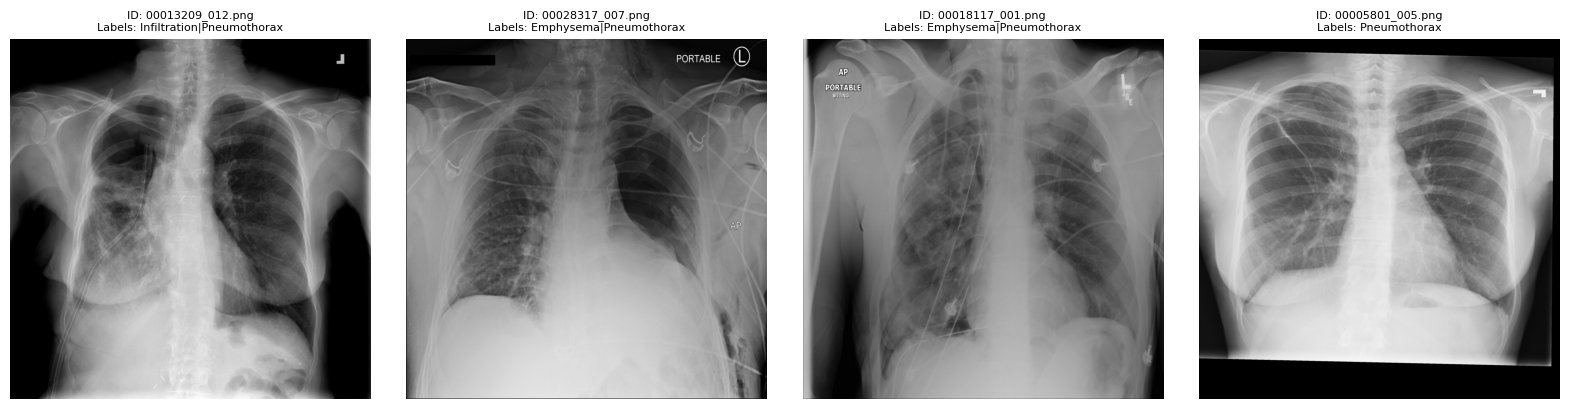

In [ ]:
def visualize_label_samples(df, label, image_dir, n=4):
    samples = get_samples_for_label(df, label, n)

    if samples is None: return

    plt.figure(figsize=(16, 4))
    for i, (idx, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(image_dir, row['Image Index'])

        # Check if file exists (crucial for NIH nested structure)
        if not os.path.exists(img_path):
            print(f"File not found: {img_path}")
            continue

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap='bone') # X-rays look best in 'bone' or gray
        plt.title(f"ID: {row['Image Index']}\nLabels: {row['Finding Labels']}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run it
image_dir = "data/sample/images" # Update this to your unzipped folder
visualize_label_samples(df, "Pneumothorax", image_dir, n=4)

In [ ]:
artifact_dir = '/content/artifacts/vit-sample:v0'
# Load the processor (standard ViT)
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
weights_path = os.path.join(artifact_dir, "best_model_20260507-035340.pth")
# Load the model from the artifact directory
vit_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=14,
    problem_type="multi_label_classification",
    ignore_mismatched_sizes=True,
    attn_implementation='eager'
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 3. Load the .pth state dictionary
state_dict = torch.load(weights_path, map_location=device)

# 4. Handle 'module.' prefix (common if you trained on Multiple GPUs/DataParallel)
if any(k.startswith('module.') for k in state_dict.keys()):
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

vit_model.load_state_dict(state_dict)
vit_model.to(device).eval()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([14])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([14, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [ ]:
# Re-load or update config for attention analysis
vit_model.config.output_attentions = True

# Example inference
# Get full paths and load images
image_dir = "data/sample/images" # Ensure this path is correct
image_paths = [os.path.join(image_dir, fname) for fname in sample_images['Image Index']]
pil_images = [Image.open(path).convert('RGB') for path in image_paths]

inputs = processor(images=pil_images, return_tensors="pt").to(device)
outputs = model(**inputs)

# outputs.attentions contains a tuple of tensors for each layer
attentions = outputs.attentions

In [ ]:
# Generate mask
# Redefine compute_rollout locally to fix the dimension handling for multi-image batches
def compute_rollout(attentions, discard_ratio=0.9):
    # attentions: tuple of (batch_size, num_heads, seq_len, seq_len)

    # Stack attentions across layers: (num_layers, batch_size, num_heads, seq_len, seq_len)
    att_mat_all = torch.stack(attentions)

    # Select the first image from the batch for visualization: (num_layers, num_heads, seq_len, seq_len)
    # The current visualization code (`pil_images[0]`) only uses the first image.
    att_mat_single_image = att_mat_all[:, 0, :, :, :]

    # Average across the heads: (num_layers, seq_len, seq_len)
    att_mat = att_mat_single_image.mean(dim=1)

    # 2. Add Identity matrix to account for residual connections
    residual_att = torch.eye(att_mat.size(-1)).to(att_mat.device)
    aug_att_mat = att_mat + residual_att
    aug_att_mat = aug_att_mat / aug_att_mat.sum(dim=-1).unsqueeze(-1)

    # 3. Recursively multiply the matrices
    joint_attentions = torch.zeros(aug_att_mat.size()).to(att_mat.device)
    joint_attentions[0] = aug_att_mat[0]

    for i in range(1, aug_att_mat.size(0)):
        joint_attentions[i] = torch.matmul(aug_att_mat[i], joint_attentions[i-1])

    # 4. Extract the attention from the CLS token (index 0) to all other patches
    v = joint_attentions[-1] # This is now (seq_len, seq_len)
    grid_size = int(np.sqrt(v.size(-1) - 1)) # Should be 14

    # v[0, 1:] extracts the attention from the CLS token to all other patches (shape: (seq_len - 1,))
    mask = v[0, 1:].reshape(grid_size, grid_size).detach().cpu().numpy()

    # 5. Normalize the mask
    mask = (mask - mask.min()) / (mask.max() - mask.min())
    return mask

In [ ]:
artifact_dir = '/content/artifacts/CheXNet-sample:v0'
from torchvision.models import densenet121, DenseNet121_Weights

# 1. Re-create the architecture exactly as it was during training
cnn_model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
cnn_model.classifier = nn.Linear(cnn_model.classifier.in_features, 14)


# 2. Load the state dict from your path
cnn_weights_path = os.path.join(artifact_dir, "best_model_20260507-031207.pth")
state_dict_cnn = torch.load(cnn_weights_path, map_location=device)

# 3. Handle the 'module.' prefix (same as you did for ViT)
if any(k.startswith('module.') for k in state_dict_cnn.keys()):
    state_dict_cnn = {k.replace('module.', ''): v for k, v in state_dict_cnn.items()}

# 4. Load weights into the model
cnn_model.load_state_dict(state_dict_cnn)
cnn_model.to(device).eval()


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 143.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=ad05455f280d8840e4d6d69a9960a7b3924e381b484aeaa937516c6db5fc661e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
boundaries = pd.read_csv(path + "/nih_data_sample/BBox_List_2017.csv")
boundaries

,Image Index,Finding Label,Bbox [x,y,w,h],Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,NaN,NaN,NaN
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,NaN,NaN,NaN
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,NaN,NaN,NaN
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,NaN,NaN,NaN
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
979,00029464_015.png,Atelectasis,198.940451,352.900747,615.537778,323.128889,NaN,NaN,NaN
980,00025769_001.png,Atelectasis,701.838229,572.491858,103.537778,63.715556,NaN,NaN,NaN
981,00016837_002.png,Atelectasis,140.913785,658.962969,271.928889,94.435556,NaN,NaN,NaN
982,00020124_003.png,Atelectasis,175.047118,580.456302,244.622222,103.537778,NaN,NaN,NaN


In [ ]:
sample_bounds = boundaries[boundaries['Image Index'].isin(df['Image Index'])].copy()
sample_bounds.drop(['Unnamed: 6','Unnamed: 7', 'Unnamed: 8'], axis=1,  inplace=True)
sample_bounds.rename(columns={'Bbox [x': 'x', 'h]': 'h'}, inplace=True)
sample_bounds.head()


,Image Index,Finding Label,x,y,w,h
26,00022883_002.png,Atelectasis,114.440678,511.222607,733.288136,108.474576
42,00030434_000.png,Atelectasis,667.661017,645.731081,75.932203,239.728814
44,00020408_037.png,Atelectasis,190.372881,632.714132,227.796610,160.542373
51,00021495_005.png,Atelectasis,541.830508,640.307352,299.389831,265.762712
82,00010481_021.png,Atelectasis,763.118644,551.864407,160.542373,68.338983


In [ ]:
import random

In [ ]:

# Load the BBox data
# df_bbox = pd.read_csv("BBox_List_2017.csv")

def get_bbox_samples_for_label(df_bbox, label, n=5):
    """
    Filters for images that have both the label AND a bounding box.
    """
    # Filter by the specific disease in the BBox list
    subset = df_bbox[df_bbox['Finding Label'] == label]

    if len(subset) == 0:
        print(f"No BBox samples found for label: {label}")
        return None

    # Pick n unique images (sometimes one image has multiple boxes)
    sample_filenames = subset['Image Index'].unique()
    actual_n = min(len(sample_filenames), n)
    chosen_filenames = random.sample(list(sample_filenames), actual_n)

    return subset[subset['Image Index'].isin(chosen_filenames)]

# Example: Get 3 Pneumothorax images that have BBoxes
target_label = "Pneumothorax"
bbox_samples = get_bbox_samples_for_label(sample_bounds, target_label, n=3)

In [ ]:
bbox_samples

,Image Index,Finding Label,x,y,w,h
884,00021748_000.png,Pneumothorax,550.115556,74.277934,167.253333,54.613333
885,00010767_008.png,Pneumothorax,203.093333,191.469045,164.977778,142.222222
951,00027652_003.png,Pneumothorax,75.851852,202.632804,145.202116,514.708995


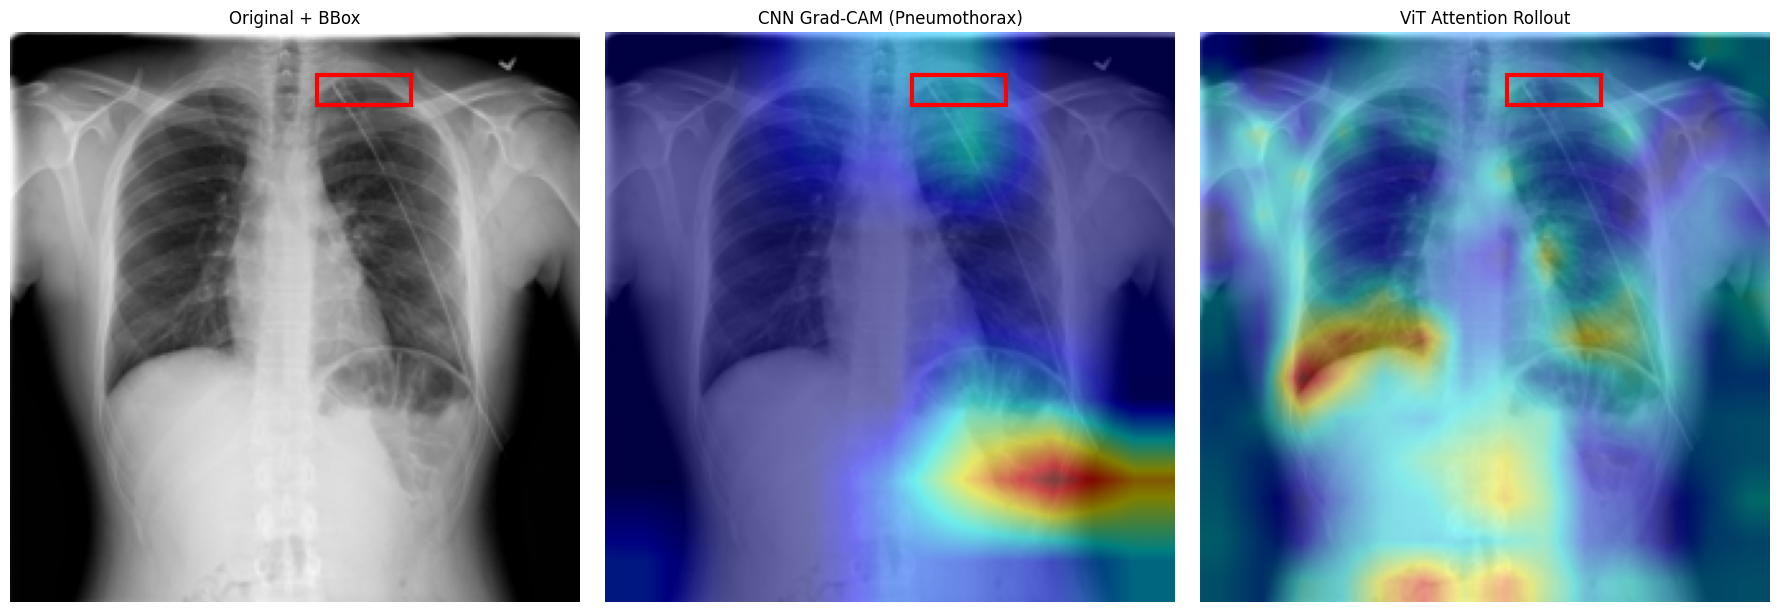

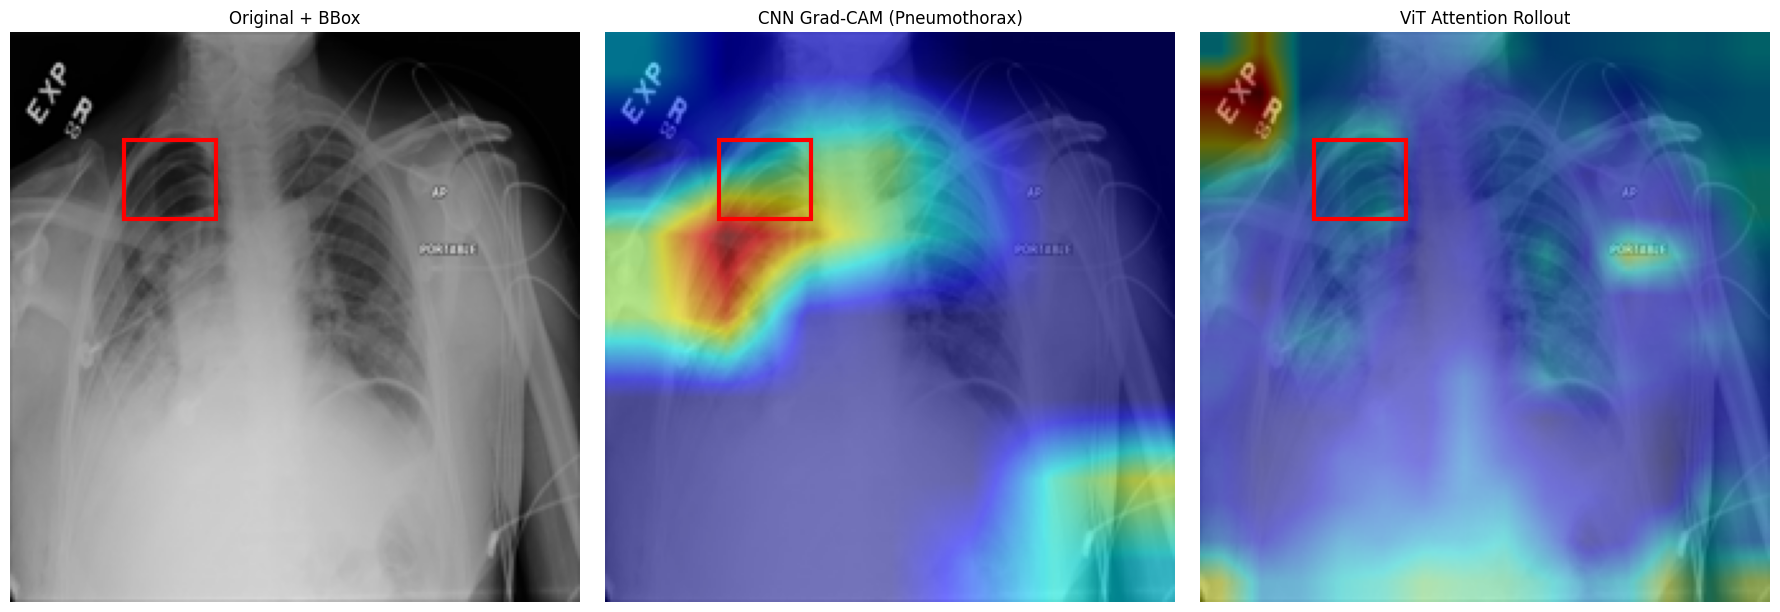

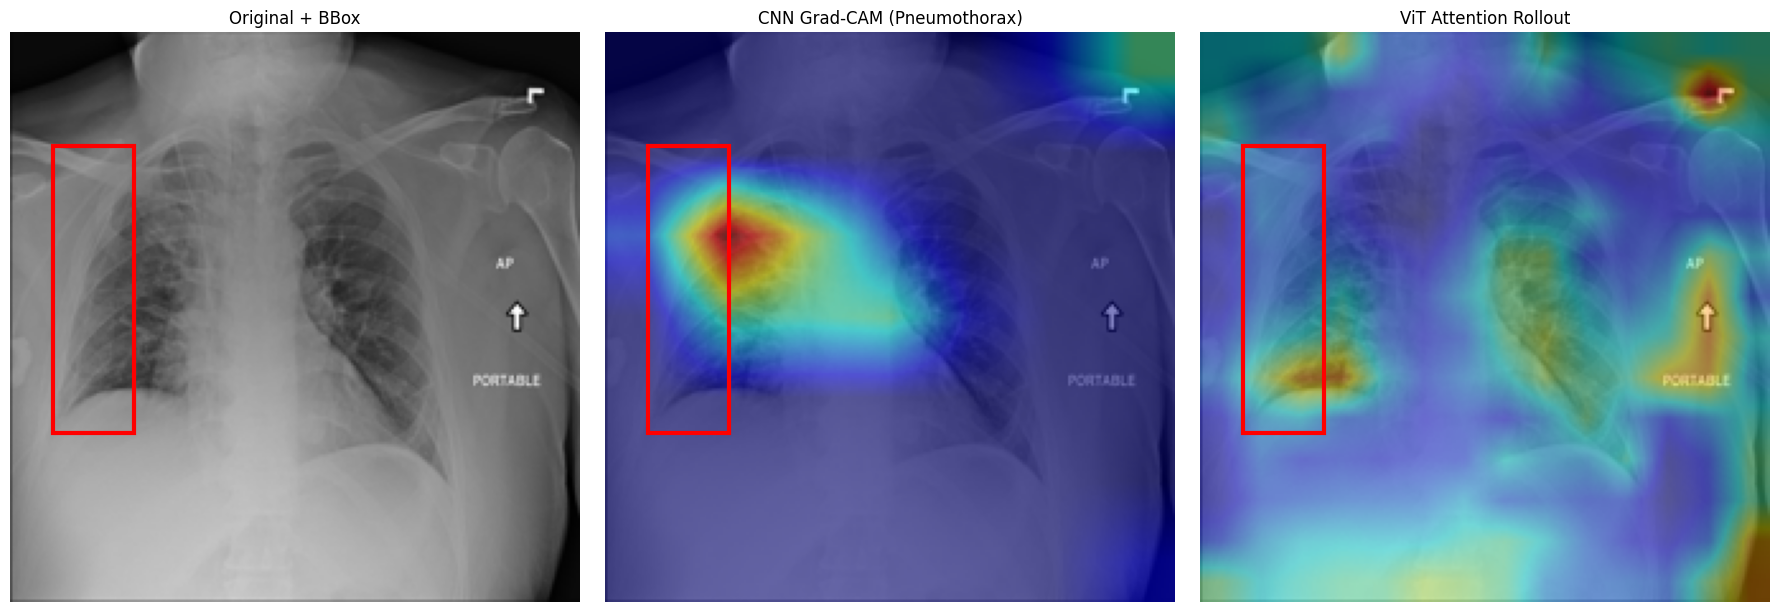

In [ ]:
import matplotlib.patches as patches

def visualize_with_ground_truth(bbox_df, target_label, disease_list):
    target_idx = disease_list.index(target_label)
    unique_images = bbox_df['Image Index'].unique()

    # Setup Grad-CAM for CNN
    target_layers_cnn = [cnn_model.features.norm5]
    cam = GradCAM(model=cnn_model, target_layers=target_layers_cnn)

    for img_name in unique_images:
        # Load Image
        path = os.path.join(image_dir, img_name)
        img_pil = Image.open(path).convert('RGB').resize((224, 224))
        rgb_norm = np.float32(img_pil) / 255

        # --- 1. CNN Grad-CAM ---
        cnn_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
        cnn_input = cnn_transform(img_pil).unsqueeze(0).to(device)
        cnn_grayscale = cam(input_tensor=cnn_input, targets=[ClassifierOutputTarget(target_idx)])[0, :]
        cnn_viz = show_cam_on_image(rgb_norm, cnn_grayscale, use_rgb=True)

        # --- 2. ViT Attention Rollout ---
        vit_inputs = processor(images=img_pil, return_tensors="pt").to(device)
        with torch.no_grad():
            vit_outputs = vit_model(**vit_inputs, output_attentions=True)
        vit_mask = compute_rollout(vit_outputs.attentions)
        vit_mask_resized = cv2.resize(vit_mask, (224, 224))
        vit_heatmap = cv2.applyColorMap(np.uint8(255 * vit_mask_resized), cv2.COLORMAP_JET)
        vit_heatmap = cv2.cvtColor(vit_heatmap, cv2.COLOR_BGR2RGB)
        vit_viz = cv2.addWeighted(np.uint8(255 * rgb_norm), 0.6, vit_heatmap, 0.4, 0)

        # --- 3. Plotting ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        titles = ["Original + BBox", f"CNN Grad-CAM ({target_label})", "ViT Attention Rollout"]
        viz_list = [np.uint8(255 * rgb_norm), cnn_viz, vit_viz]

        # Get all bboxes for this image
        img_boxes = bbox_df[bbox_df['Image Index'] == img_name]

        for ax, viz, title in zip(axes, viz_list, titles):
            ax.imshow(viz)
            ax.set_title(title)

            # Draw each BBox (Scaled from 1024 to 224)
            for _, row in img_boxes.iterrows():
                scale = 224 / 1024
                rect = patches.Rectangle(
                    (row['x'] * scale, row['y'] * scale),
                    row['w'] * scale, row['h'] * scale,
                    linewidth=3, edgecolor='red', facecolor='none'
                )
                ax.add_patch(rect)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

# Run it!
visualize_with_ground_truth(bbox_samples, "Pneumothorax", disease_list)

In [ ]:
import matplotlib.pyplot as plt

def visualize_hybrid_results(model, bbox_df, target_label, disease_list):
    model.eval()
    target_idx = disease_list.index(target_label)

    unique_images = bbox_df['Image Index'].unique()

    # Setup Grad-CAM for CNN
    target_layers_cnn = [model.cnn.features.norm5]
    cam = GradCAM(model=model.cnn, target_layers=target_layers_cnn)

    for img_name in unique_images:
        # Load Image
        path = os.path.join(image_dir, img_name)
        img_pil = Image.open(path).convert('RGB').resize((224, 224))
        rgb_norm = np.float32(img_pil) / 255


        # 2. Extract CNN Grad-CAM
        # We target the 'cnn' attribute inside your Hybrid class
        cnn_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
        img_tensor = cnn_transform(img_pil).unsqueeze(0).to(device)
        cnn_grayscale = cam(input_tensor=img_tensor, targets=[ClassifierOutputTarget(target_idx)])[0, :]
        cnn_viz = show_cam_on_image(rgb_norm, cnn_grayscale, use_rgb=True)

        # 3. Extract ViT Attention Rollout
        # We pass the image through model.vit specifically
        with torch.no_grad():
            vit_outputs = model.vit(img_tensor, output_attentions=True)

        vit_mask = compute_rollout(vit_outputs.attentions)
        vit_mask_resized = cv2.resize(vit_mask, (224, 224))
        vit_heatmap = cv2.applyColorMap(np.uint8(255 * vit_mask_resized), cv2.COLORMAP_JET)
        vit_heatmap = cv2.cvtColor(vit_heatmap, cv2.COLOR_BGR2RGB)
        vit_viz = cv2.addWeighted(np.uint8(255 * rgb_norm), 0.6, vit_heatmap, 0.4, 0)

        # 4. Plotting
        # --- 3. Plotting ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        titles = ["Original + BBox", f"Hybrid-CNN Part ({target_label})", "Hybrid-ViT Part"]
        viz_list = [np.uint8(255 * rgb_norm), cnn_viz, vit_viz]

        # Get all bboxes for this image
        img_boxes = bbox_df[bbox_df['Image Index'] == img_name]

        for ax, viz, title in zip(axes, viz_list, titles):
            ax.imshow(viz)
            ax.set_title(title)

            # Draw each BBox (Scaled from 1024 to 224)
            for _, row in img_boxes.iterrows():
                scale = 224 / 1024
                rect = patches.Rectangle(
                    (row['x'] * scale, row['y'] * scale),
                    row['w'] * scale, row['h'] * scale,
                    linewidth=3, edgecolor='red', facecolor='none'
                )
                ax.add_patch(rect)
            ax.axis('off')

        plt.tight_layout()
        plt.show()
        plt.show()

# visualize_hybrid_results(hybrid_model, "test_xray.png", "Pneumothorax", disease_labels)

In [ ]:
sample_bounds['Finding Label'].value_counts()

,count
Finding Label,
Atelectasis,11
Cardiomegaly,10
Pneumonia,9
Effusion,8
Pneumothorax,6
Mass,4
Nodule,3
Infiltrate,2


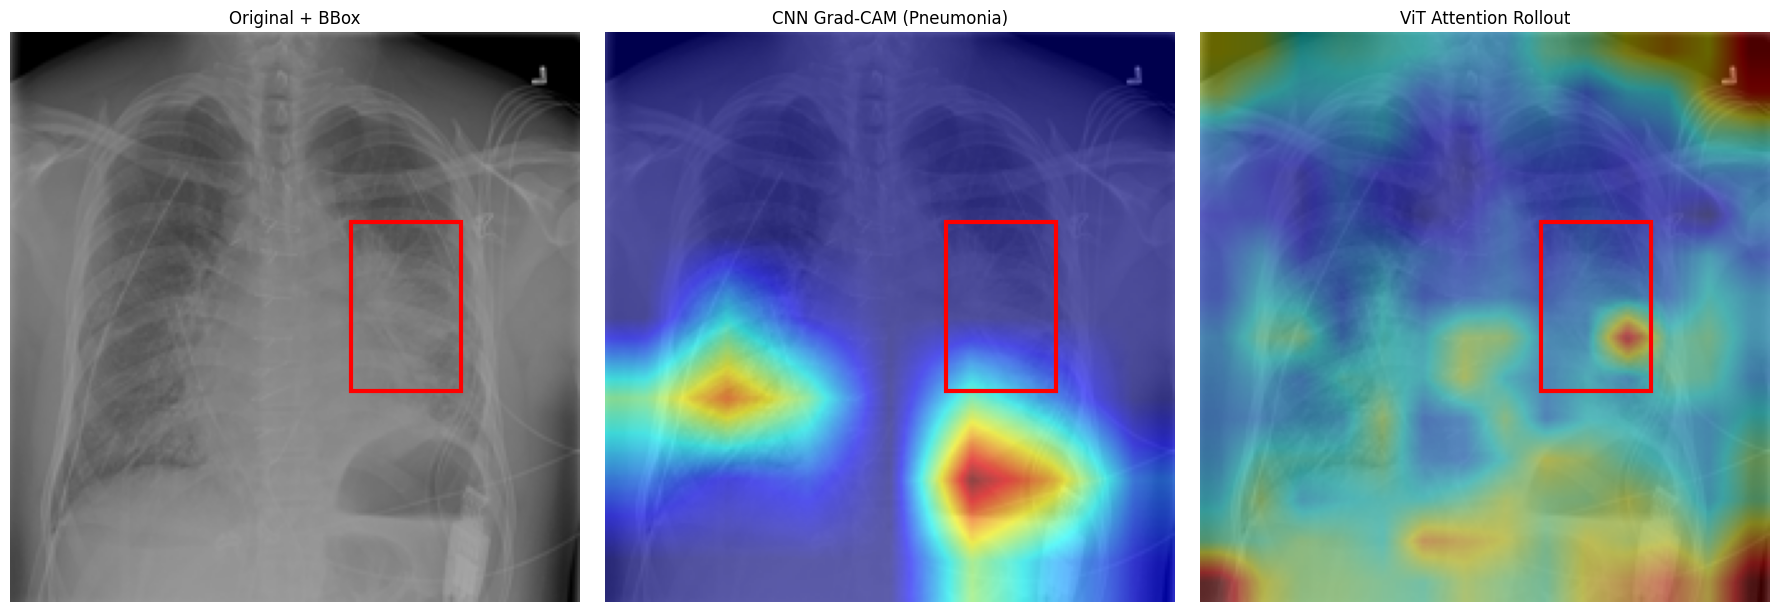

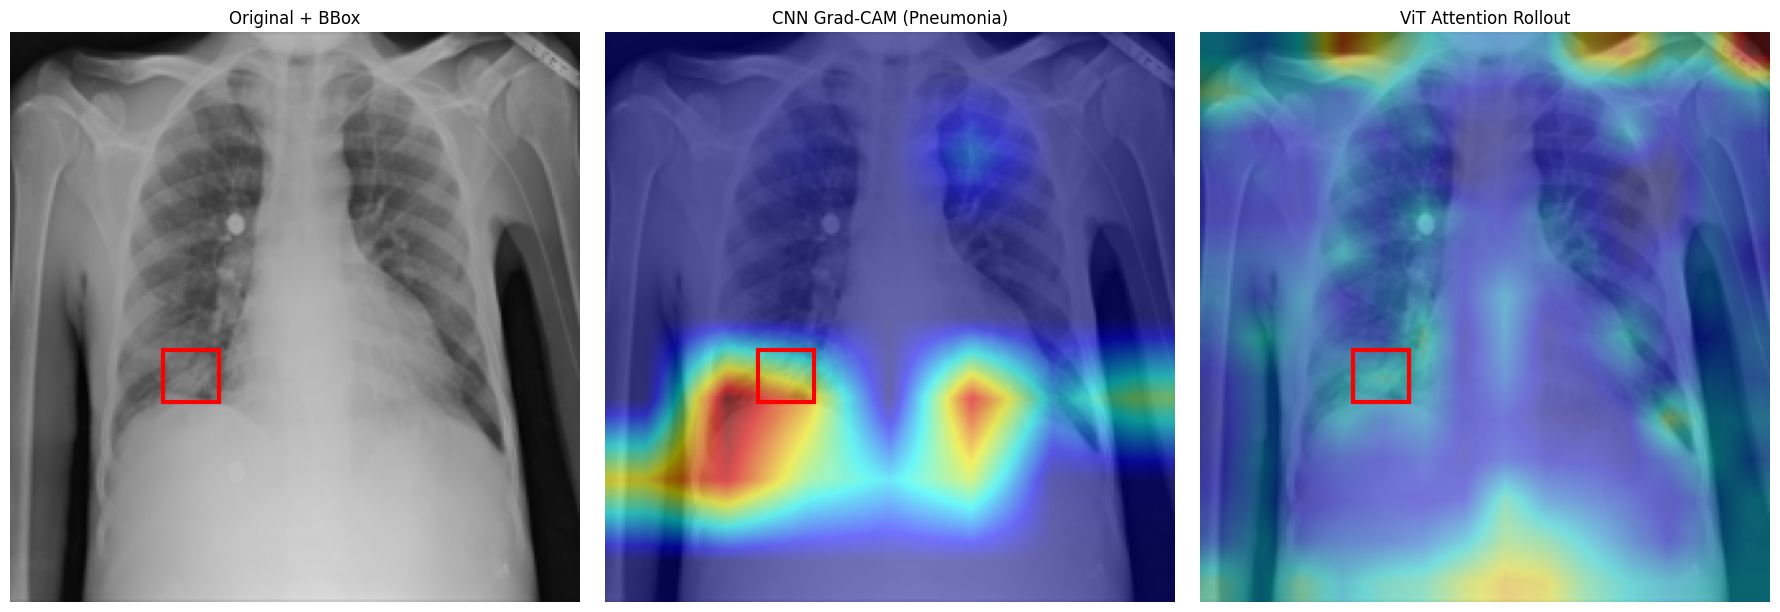

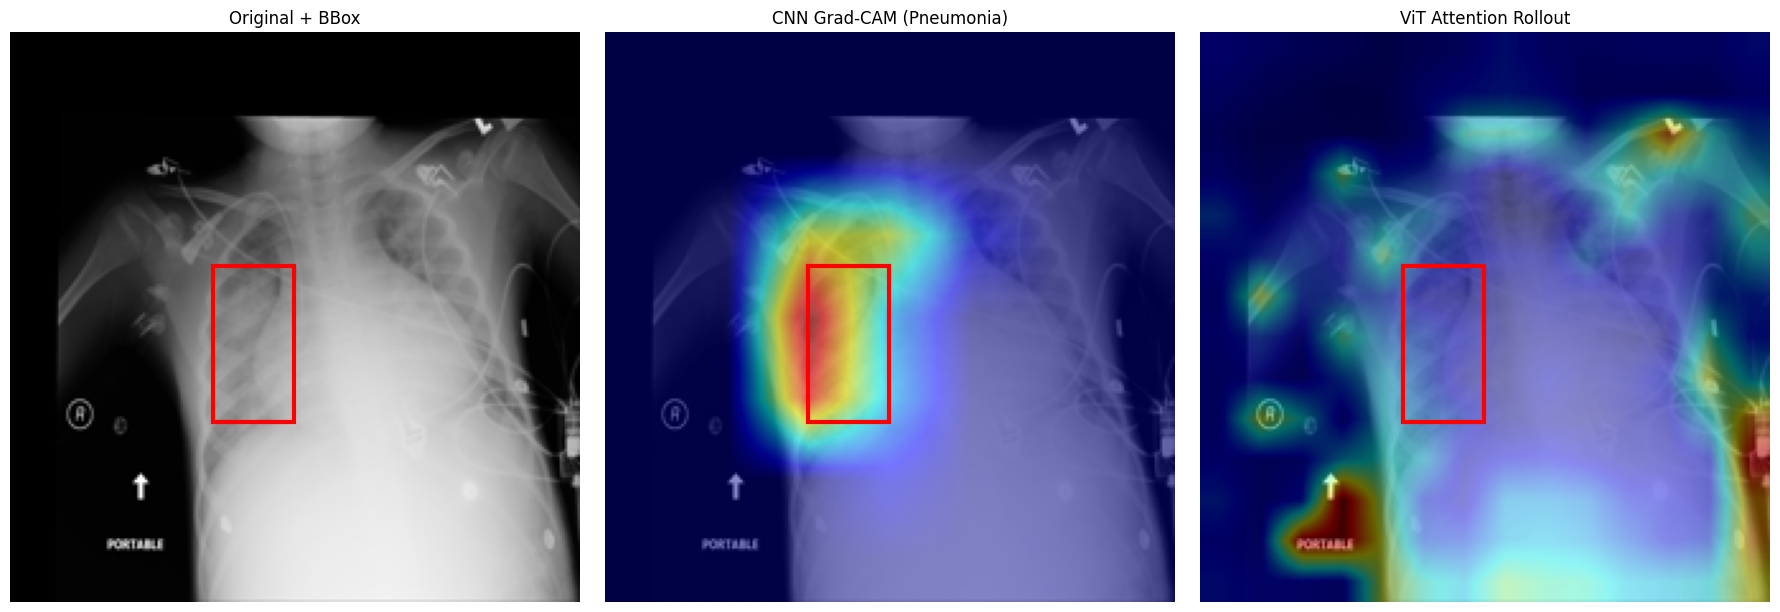

In [ ]:
target_label = "Pneumonia"
bbox_samples = get_bbox_samples_for_label(sample_bounds, target_label, n=3)
visualize_with_ground_truth(bbox_samples, target_label, disease_list)

In [ ]:
# Initialize a new HybridModel instance
# The HybridModel class is defined in cell GATGeUjXLKvR
loaded_hybrid_model = HybridModel(num_labels=14).to(CONFIG["device"])

# Load the state dictionary from the best checkpoint
# The best_checkpoint_path variable is available in the kernel state
checkpoint_path_for_loading = best_checkpoint_path # e.g., 'models/20260508-080054/best_model_20260508-081058.pth'

print(f"Loading hybrid model from: {checkpoint_path_for_loading}")
loaded_hybrid_model.load_state_dict(torch.load(checkpoint_path_for_loading, map_location=CONFIG["device"]))
loaded_hybrid_model.eval()

# Update the 'hybrid_model' variable for subsequent use
hybrid_model = loaded_hybrid_model

print("Hybrid model successfully loaded and set to 'hybrid_model' variable.")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading hybrid model from: models/20260508-080054/best_model_20260508-081058.pth
Hybrid model successfully loaded and set to 'hybrid_model' variable.


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from torchvision import transforms

from pytorch_grad_cam import AblationCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.ablation_layer import AblationLayerVit


# =========================================================
# Helper: Attention Rollout for ViT
# =========================================================

def compute_rollout(attentions, discard_ratio=0.0):

    result = torch.eye(attentions[0].size(-1)).to(attentions[0].device)

    with torch.no_grad():

        for attention in attentions:

            attention_heads_fused = attention.mean(axis=1)

            flat = attention_heads_fused.view(
                attention_heads_fused.size(0),
                -1
            )

            _, indices = flat.topk(
                int(flat.size(-1) * discard_ratio),
                -1,
                False
            )

            flat[0, indices] = 0

            identity = torch.eye(
                attention_heads_fused.size(-1)
            ).to(attention.device)

            a = (attention_heads_fused + identity) / 2
            a = a / a.sum(dim=-1, keepdim=True)

            result = torch.matmul(a, result)

    mask = result[0, 0, 1:]

    width = int(mask.size(-1) ** 0.5)

    mask = mask.reshape(width, width).cpu().numpy()

    mask = mask / mask.max()

    return mask


# =========================================================
# MAIN VISUALIZATION FUNCTION
# =========================================================

def visualize_hybrid_ablationcam(
    model,
    bbox_df,
    target_label,
    disease_list,
):

    model.eval()

    target_idx = disease_list.index(target_label)

    unique_images = bbox_df["Image Index"].unique()

    # =====================================================
    # IMAGE TRANSFORM
    # =====================================================

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    # =====================================================
    # CNN AblationCAM
    # =====================================================

    cnn_target_layers = [model.cnn.features.denseblock4]

    cnn_cam = AblationCAM(
        model=model,
        target_layers=cnn_target_layers
    )

    # =====================================================
    # ViT AblationCAM
    # =====================================================

    vit_target_layers = [model.vit.encoder.layer[-1].layernorm_after]

    vit_cam = AblationCAM(
        model=model,
        target_layers=vit_target_layers,
        ablation_layer=AblationLayerVit()
    )

    # =====================================================
    # LOOP OVER IMAGES
    # =====================================================

    for img_name in unique_images:

        print(f"\nProcessing: {img_name}")

        # -------------------------------------------------
        # LOAD IMAGE
        # -------------------------------------------------

        path = os.path.join(image_dir, img_name)

        img_pil = Image.open(path).convert("RGB").resize((224, 224))

        rgb_img = np.float32(img_pil) / 255

        input_tensor = transform(img_pil).unsqueeze(0).to(device)

        targets = [ClassifierOutputTarget(target_idx)]

        # =================================================
        # CNN CONTRIBUTION (AblationCAM)
        # =================================================

        cnn_grayscale_cam = cnn_cam(
            input_tensor=input_tensor,
            targets=targets
        )[0, :]

        cnn_visualization = show_cam_on_image(
            rgb_img,
            cnn_grayscale_cam,
            use_rgb=True
        )

        # =================================================
        # ViT CONTRIBUTION (Attention Rollout)
        # =================================================

        with torch.no_grad():

            vit_outputs = model.vit(
                pixel_values=input_tensor,
                output_attentions=True
            )

        vit_mask = compute_rollout(vit_outputs.attentions)

        vit_mask_resized = cv2.resize(vit_mask, (224, 224))

        vit_heatmap = cv2.applyColorMap(
            np.uint8(255 * vit_mask_resized),
            cv2.COLORMAP_JET
        )

        vit_heatmap = cv2.cvtColor(
            vit_heatmap,
            cv2.COLOR_BGR2RGB
        )

        vit_visualization = cv2.addWeighted(
            np.uint8(255 * rgb_img),
            0.6,
            vit_heatmap,
            0.4,
            0
        )

        # =================================================
        # HYBRID MODEL PREDICTION
        # =================================================

        with torch.no_grad():

            logits = model(input_tensor)

            probs = torch.sigmoid(logits)[0]

            pred_prob = probs[target_idx].item()

        # =================================================
        # PLOTTING
        # =================================================

        fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        titles = [
            "Original + BBox",
            f"CNN Contribution ({target_label})",
            f"ViT Contribution ({target_label})"
        ]

        viz_list = [
            np.uint8(255 * rgb_img),
            cnn_visualization,
            vit_visualization
        ]

        img_boxes = bbox_df[
            bbox_df["Image Index"] == img_name
        ]

        for ax, viz, title in zip(axes, viz_list, titles):

            ax.imshow(viz)

            ax.set_title(title)

            # ---------------------------------------------
            # DRAW BOUNDING BOXES
            # ---------------------------------------------

            for _, row in img_boxes.iterrows():

                scale = 224 / 1024

                rect = patches.Rectangle(
                    (
                        row["x"] * scale,
                        row["y"] * scale
                    ),
                    row["w"] * scale,
                    row["h"] * scale,
                    linewidth=3,
                    edgecolor="lime",
                    facecolor="none"
                )

                ax.add_patch(rect)

            ax.axis("off")

        plt.suptitle(
            f"{target_label} | Prediction Probability: {pred_prob:.4f}",
            fontsize=16
        )

        plt.tight_layout()

        plt.show()


Processing: 00029808_003.png


100%|██████████| 32/32 [00:03<00:00,  8.95it/s]


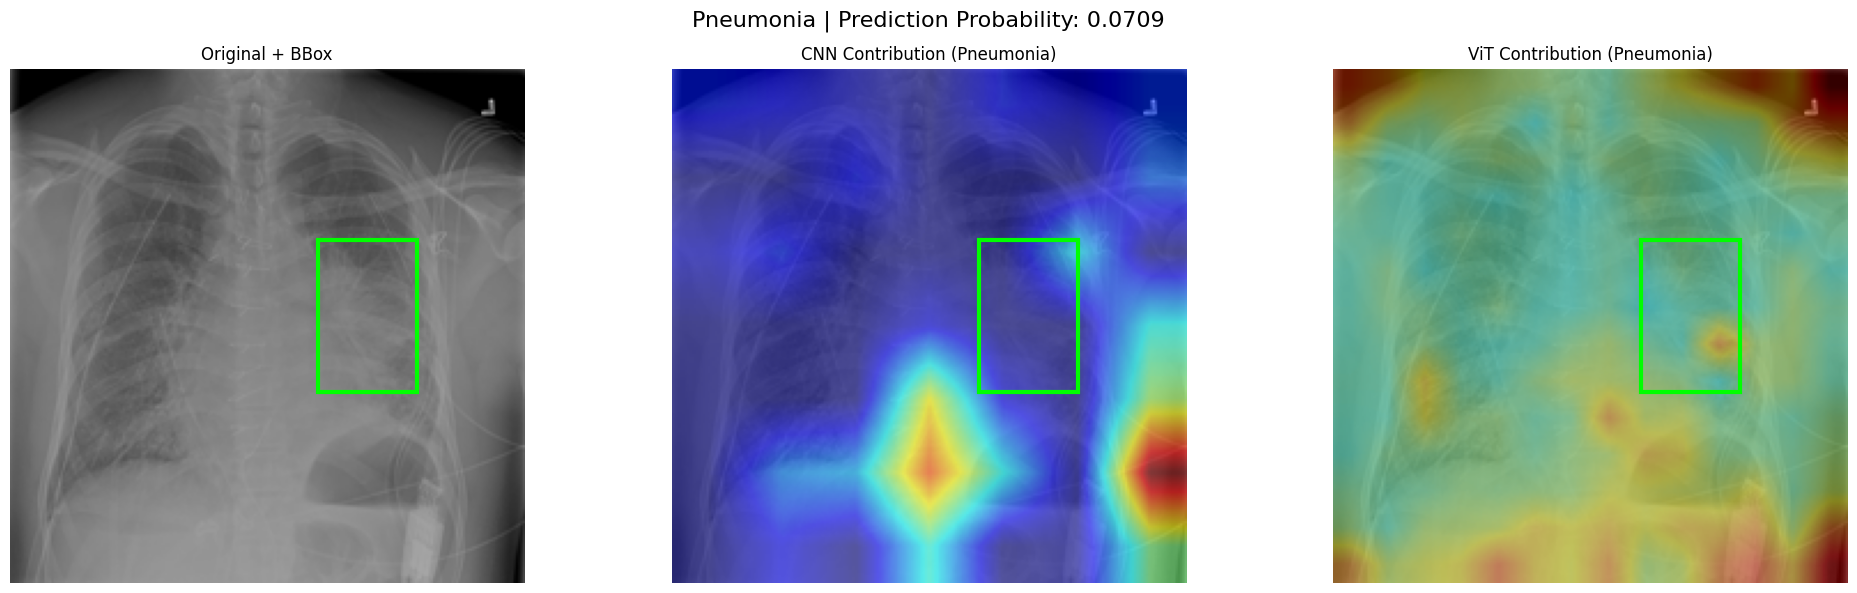


Processing: 00003789_000.png


100%|██████████| 32/32 [00:03<00:00,  9.25it/s]


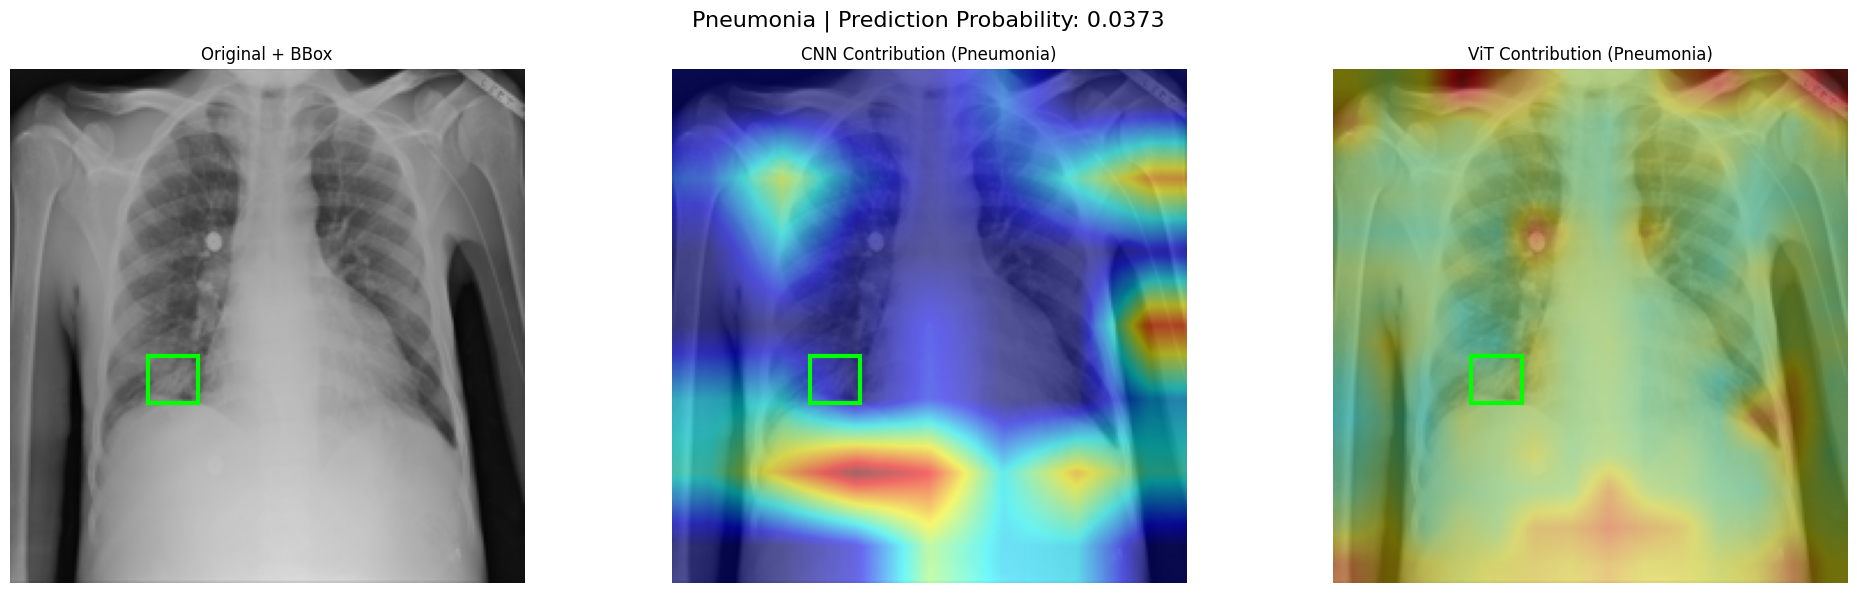


Processing: 00013249_033.png


100%|██████████| 32/32 [00:03<00:00,  9.19it/s]


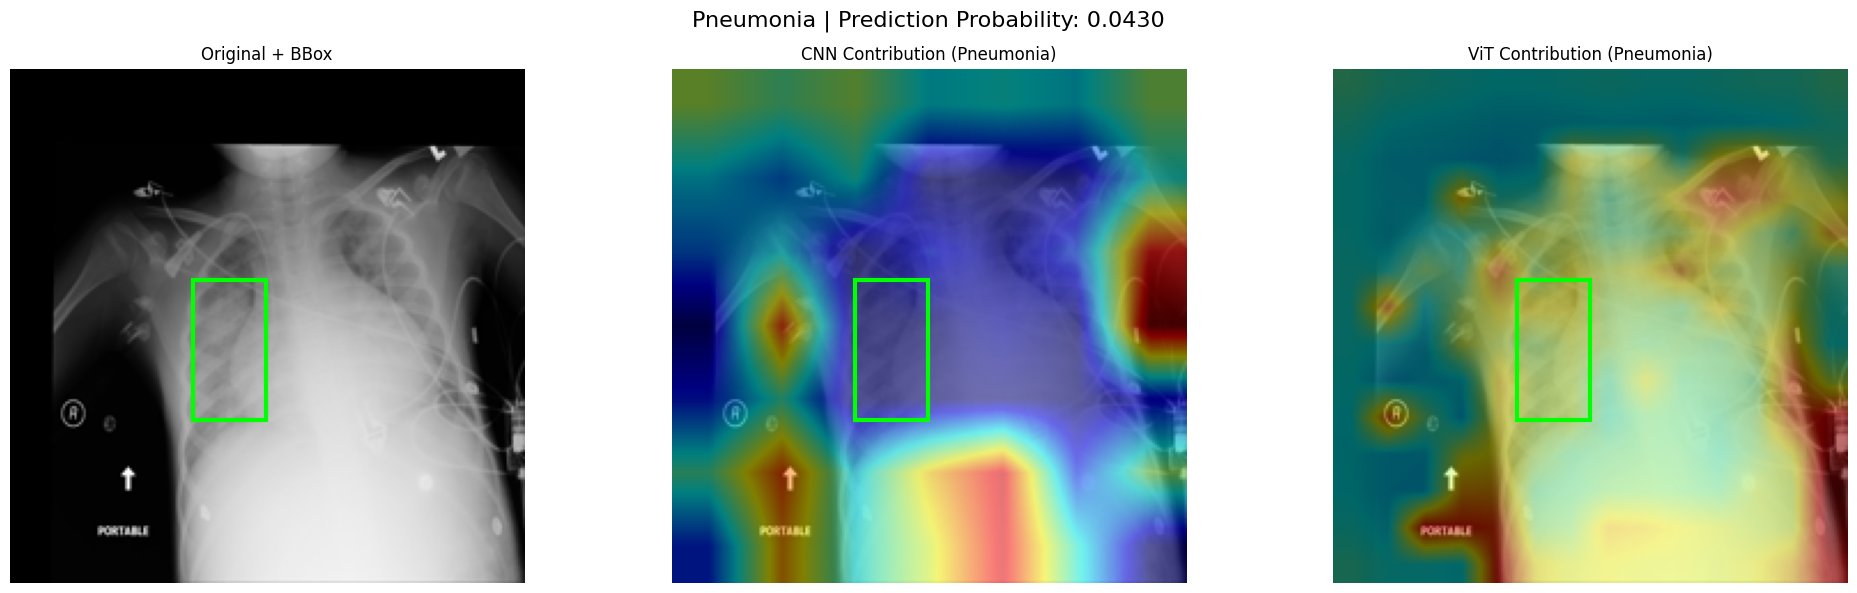

In [ ]:
visualize_hybrid_ablationcam(hybrid_model,bbox_samples, target_label, disease_list)

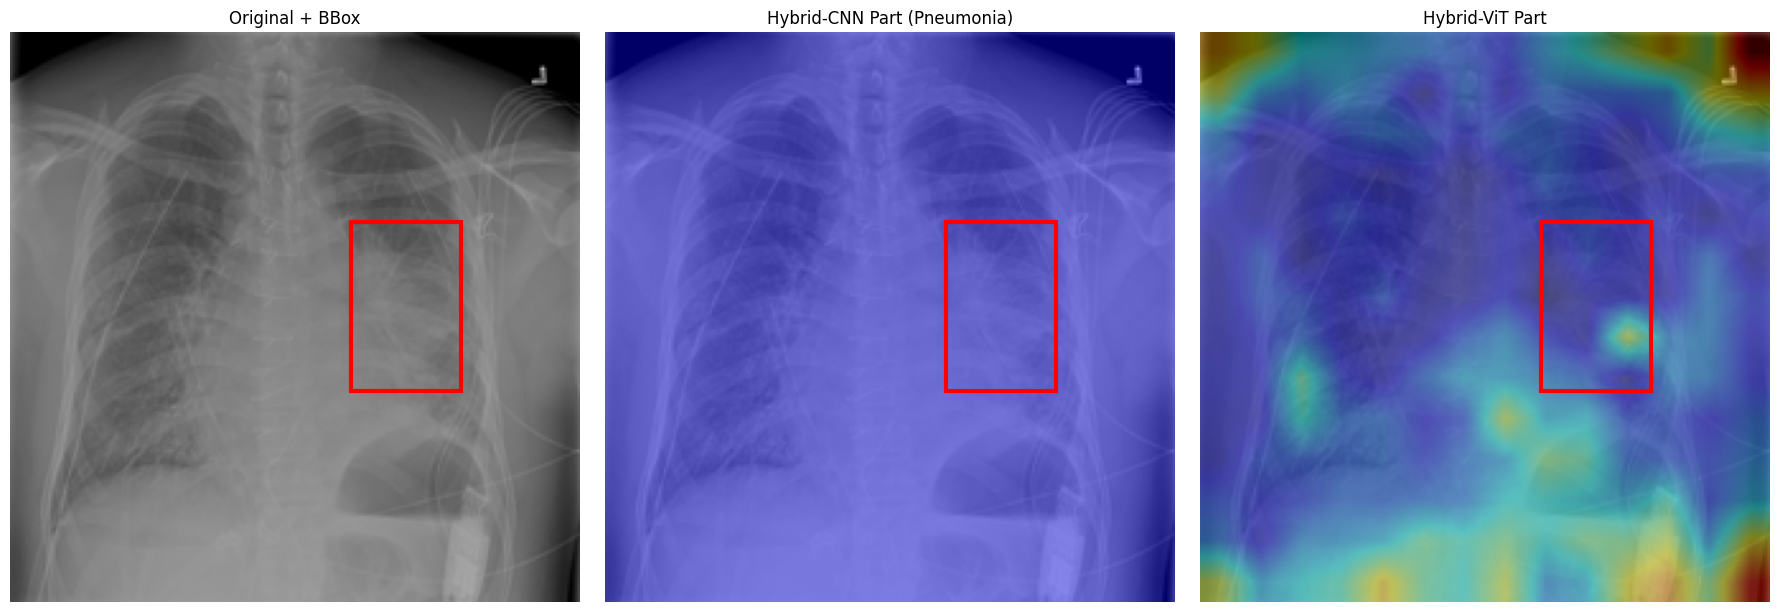

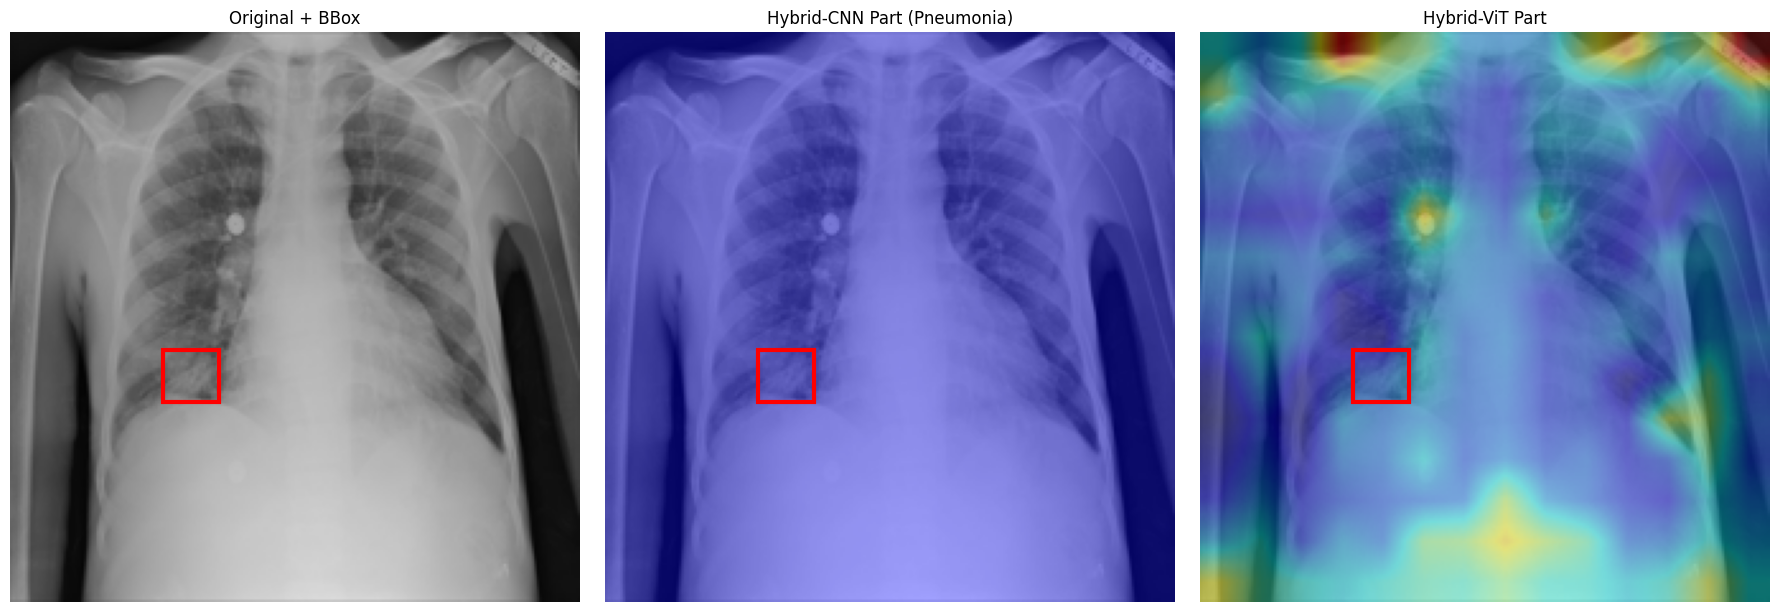

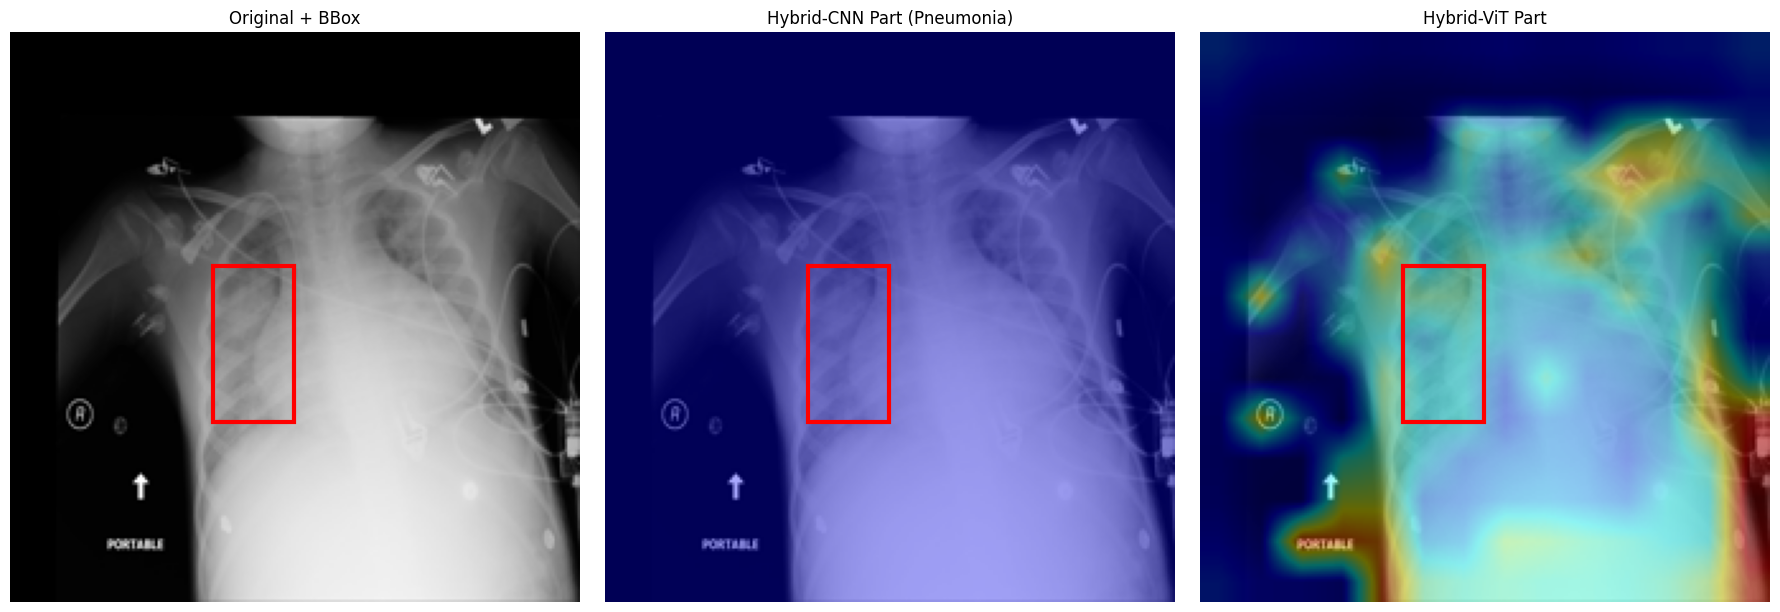

In [ ]:
visualize_hybrid_results(hybrid_model,bbox_samples, target_label, disease_list)

In [ ]:
import torch

# Ensure the model is on the correct device
device = CONFIG["device"]
hybrid_model.to(device)

# Access the first linear layer in the classifier
# The classifier is defined as nn.Sequential, so the first linear layer is at index 0
first_linear_layer = hybrid_model.classifier[0]

# Get the weights of this layer
# Detach from the computation graph and move to CPU for easier analysis if not already there
weights = first_linear_layer.weight.cpu().detach()

# Define the split point for CNN (DenseNet121) and ViT features
# After projection layers, both CNN and ViT features are 512 dimensions each
cnn_feature_dim = 512 # After cnn_proj
vit_feature_dim = 512 # After vit_proj
total_feature_dim = cnn_feature_dim + vit_feature_dim # 512 + 512 = 1024

if weights.shape[1] != total_feature_dim:
    print(f"Warning: Expected input feature dimension {total_feature_dim}, but got {weights.shape[1]}.")
    print("This might indicate a mismatch in model definition or unexpected state.")

# Split the weights into CNN and ViT parts
# The first 512 columns correspond to projected CNN features
# The next 512 columns correspond to projected ViT features
cnn_weights_part = weights[:, :cnn_feature_dim]
vit_weights_part = weights[:, cnn_feature_dim:]

# Calculate the sum of absolute values for each part
# This gives a measure of the total 'strength' of connections from each component
cnn_total_abs_weight = cnn_weights_part.abs().sum().item()
vit_total_abs_weight = vit_weights_part.abs().sum().item()

total_abs_weight = cnn_total_abs_weight + vit_total_abs_weight

print(f"--- Hybrid Model Feature Weight Analysis ---")
print(f"Total absolute weight of CNN features in the first classifier layer: {cnn_total_abs_weight:.4f}")
print(f"Total absolute weight of ViT features in the first classifier layer: {vit_total_abs_weight:.4f}")

if total_abs_weight == 0:
    print("Total absolute weight is zero, cannot calculate percentages.")
else:
    cnn_percentage = (cnn_total_abs_weight / total_abs_weight) * 100
    vit_percentage = (vit_total_abs_weight / total_abs_weight) * 100

    print(f"\nRelative contribution to the first hidden layer (based on absolute sum of weights):")
    print(f"  CNN Features: {cnn_percentage:.2f}%")
    print(f"  ViT Features: {vit_percentage:.2f}%")

# Calculate and print the average absolute weight per feature dimension for a more granular view
cnn_avg_magnitude_per_dim = cnn_weights_part.abs().mean().item()
vit_avg_magnitude_per_dim = vit_weights_part.abs().mean().item()

print(f"\nAverage absolute weight per individual CNN feature dimension: {cnn_avg_magnitude_per_dim:.4f}")
print(f"Average absolute weight per individual ViT feature dimension: {vit_avg_magnitude_per_dim:.4f}")


--- Hybrid Model Feature Weight Analysis ---
Total absolute weight of CNN features in the first classifier layer: 4178.4365
Total absolute weight of ViT features in the first classifier layer: 4138.2720

Relative contribution to the first hidden layer (based on absolute sum of weights):
  CNN Features: 50.24%
  ViT Features: 49.76%

Average absolute weight per individual CNN feature dimension: 0.0159
Average absolute weight per individual ViT feature dimension: 0.0158
